In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from typing import Dict, Any, Optional, List

plt.style.use("ggplot")

In [2]:
os.getcwd()

'/home/jterryc/KOMOREBI-PROJECT/notebooks'

In [3]:
os.listdir(".")

['EDA_jtc.ipynb', 'notebooks.txt', 'EDA_jon.ipynb']

In [4]:
wd_local_path = '../data/zrive_advertiser_withdrawals.parquet'
dim_local_path = '../data/zrive_dim_advertiser.parquet'
fct_local_path = '../data/zrive_fct_monthly_snapshot_advertiser.parquet'

In [5]:
df_wd = pd.read_parquet(wd_local_path, engine='fastparquet')
df_dim = pd.read_parquet(dim_local_path, engine='fastparquet')


### Witdrawals

In [6]:
df_wd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22668 entries, 0 to 22667
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   withdrawal_id              22668 non-null  int64         
 1   advertiser_zrive_id        22668 non-null  int64         
 2   withdrawal_status          22668 non-null  object        
 3   withdrawal_type            22668 non-null  object        
 4   withdrawal_creation_date   22668 non-null  datetime64[us]
 5   withdrawal_effective_date  14348 non-null  datetime64[ns]
 6   withdrawal_reason          22668 non-null  object        
dtypes: datetime64[ns](1), datetime64[us](1), int64(2), object(3)
memory usage: 1.2+ MB


In [7]:
df_wd.isna().sum()

withdrawal_id                   0
advertiser_zrive_id             0
withdrawal_status               0
withdrawal_type                 0
withdrawal_creation_date        0
withdrawal_effective_date    8320
withdrawal_reason               0
dtype: int64

In [8]:
float(df_wd.withdrawal_effective_date.isnull().sum()/df_wd.shape[0])

0.36703723310393505

- 36.7% de valores faltantes en la columna "withdrawal_effective_date" (no viene explicada en la memoria)
- Tiene un gran porcentaje de valores faltantes, con lo cual no parece que sean MAR (Missing At Random)

In [9]:
df_wd

,withdrawal_id,advertiser_zrive_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason
0,0,259,Cerrada,TOTAL,2012-06-19 07:12:34,2012-07-01,RESULTADOS
1,1,221,Cerrada,TOTAL,2012-06-19 07:16:34,NaT,RESULTADOS
2,7,492,Cerrada,TOTAL,2012-06-20 07:10:16,2012-07-01,RESULTADOS
3,12,481,Cerrada,TOTAL,2012-06-20 11:59:36,2012-07-01,RESULTADOS
4,16,457,Cerrada,TOTAL,2012-06-20 15:41:39,2012-07-01,FALTA DE USO/TIEMPO
...,...,...,...,...,...,...,...
22663,55613,684,Cerrada,TOTAL,2025-05-30 10:57:08,2025-08-01,RATIO RESULTADO-INVERSION
22664,55614,251,Cerrada,TOTAL,2025-05-30 10:58:12,2025-08-01,RATIO RESULTADO-INVERSION
22665,55615,80,Cerrada,TOTAL,2025-05-30 10:59:03,2025-08-01,RATIO RESULTADO-INVERSION
22666,55616,5149,Cerrada,TOTAL,2025-05-30 11:15:01,2025-07-01,MOROSIDAD


In [10]:
df_wd.shape

(22668, 7)

In [11]:
def print_unique(df: pd.DataFrame, column: str = None):
    if column is None:
        for col in df.columns:
            if df[col].dtype == object:
                print(f"- {col} ({df[col].nunique()}): {df[col].unique()}")
    else:
        print(f"- {column} ({df[column].nunique()}): {df[column].unique()}")

print_unique(df_wd)

- withdrawal_status (3): ['Cerrada' 'Denegada' 'Pendiente Administración']
- withdrawal_type (2): ['TOTAL' 'PARCIAL']
- withdrawal_reason (18): ['RESULTADOS' 'FALTA DE USO/TIEMPO' 'RAZONES ECONOMICAS' 'MOROSIDAD'
 'RATIO RESULTADO-INVERSION' 'OTROS' 'FALTA DE PRODUCTO'
 'CESE DE ACTIVIDAD' 'FIN DE CONTRATO' 'Cambio a Bundle Online'
 'Baja Bundle AS24' 'Upselling-cambio de contrato' 'No acepta subida'
 'CORONAVIRUS' 'Cambio de Contrato/propuesta/producto'
 'Incidencias de la web' 'Reestructuración cuentas de grupo' 'Desconocido']


In [12]:
withdrawal_reason_not = ['Upselling-cambio de contrato', 'Cambio a Bundle Online','Cambio de Contrato/propuesta/producto']
withdrawal_reason_yes = [reason for reason in df_wd.withdrawal_reason.unique() if reason not in withdrawal_reason_not]

In [13]:
df_wd["is_definitive_withdrawal"] = (
    df_wd.withdrawal_reason.isin(withdrawal_reason_yes) &
    (df_wd.withdrawal_type == "TOTAL") &
    (df_wd.withdrawal_status != "Denegada")
).astype(int)
df_wd

,withdrawal_id,advertiser_zrive_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal
0,0,259,Cerrada,TOTAL,2012-06-19 07:12:34,2012-07-01,RESULTADOS,1
1,1,221,Cerrada,TOTAL,2012-06-19 07:16:34,NaT,RESULTADOS,1
2,7,492,Cerrada,TOTAL,2012-06-20 07:10:16,2012-07-01,RESULTADOS,1
3,12,481,Cerrada,TOTAL,2012-06-20 11:59:36,2012-07-01,RESULTADOS,1
4,16,457,Cerrada,TOTAL,2012-06-20 15:41:39,2012-07-01,FALTA DE USO/TIEMPO,1
...,...,...,...,...,...,...,...,...
22663,55613,684,Cerrada,TOTAL,2025-05-30 10:57:08,2025-08-01,RATIO RESULTADO-INVERSION,1
22664,55614,251,Cerrada,TOTAL,2025-05-30 10:58:12,2025-08-01,RATIO RESULTADO-INVERSION,1
22665,55615,80,Cerrada,TOTAL,2025-05-30 10:59:03,2025-08-01,RATIO RESULTADO-INVERSION,1
22666,55616,5149,Cerrada,TOTAL,2025-05-30 11:15:01,2025-07-01,MOROSIDAD,1


In [14]:
df_wd[df_wd.is_definitive_withdrawal == 1].withdrawal_reason.unique()

array(['RESULTADOS', 'FALTA DE USO/TIEMPO', 'RAZONES ECONOMICAS',
       'MOROSIDAD', 'RATIO RESULTADO-INVERSION', 'OTROS',
       'FALTA DE PRODUCTO', 'CESE DE ACTIVIDAD', 'FIN DE CONTRATO',
       'Baja Bundle AS24', 'No acepta subida', 'CORONAVIRUS',
       'Incidencias de la web', 'Reestructuración cuentas de grupo',
       'Desconocido'], dtype=object)

In [15]:
df_wd[df_wd.is_definitive_withdrawal == 0]

,withdrawal_id,advertiser_zrive_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal
63,352,883,Denegada,TOTAL,2012-09-26 08:27:14,NaT,MOROSIDAD,0
437,2309,314,Cerrada,PARCIAL,2013-11-19 14:25:49,NaT,MOROSIDAD,0
439,2329,851,Cerrada,PARCIAL,2013-11-19 16:23:46,2013-12-01,FIN DE CONTRATO,0
441,2336,267,Cerrada,PARCIAL,2013-11-25 08:14:37,2013-12-01,FIN DE CONTRATO,0
444,2357,355,Cerrada,PARCIAL,2013-11-28 12:02:49,NaT,RAZONES ECONOMICAS,0
...,...,...,...,...,...,...,...,...
22644,55594,6999,Cerrada,TOTAL,2025-05-29 15:06:44,2025-05-29,Upselling-cambio de contrato,0
22646,55596,1405,Cerrada,PARCIAL,2025-05-30 06:53:33,2025-05-30,Cambio de Contrato/propuesta/producto,0
22652,55602,6857,Cerrada,TOTAL,2025-05-30 07:52:10,2025-05-31,Cambio de Contrato/propuesta/producto,0
22658,55608,3866,Cerrada,TOTAL,2025-05-30 09:36:59,2025-05-30,Cambio de Contrato/propuesta/producto,0


In [16]:
real_withdrawal_pct = df_wd[df_wd["is_definitive_withdrawal"] == 1].shape[0]/df_wd.shape[0]
real_withdrawal_pct

0.7032380448208929

Si se consideran bajas definitivas aquellas donde se cumplen estas 3 condiciones simultáneamente:
1. withdrawal_type = 'TOTAL'
2. withdrawal_status != 'Denegada'
3. withdrawal_reason not in ('Upselling-cambio de contrato', 'Cambio a Bundle Online',
'Cambio de Contrato/propuesta/producto')

Obtenemos que el 70.71% de registros de posibles abandonos fueron abandonos definitivos

Pregunta: a partir de ahora, ¿nos importa el df sólo cuando is_permanent_withdrawal = 1, o con ambos casos posibles?

In [17]:
df_wd.isnull().sum()

withdrawal_id                   0
advertiser_zrive_id             0
withdrawal_status               0
withdrawal_type                 0
withdrawal_creation_date        0
withdrawal_effective_date    8320
withdrawal_reason               0
is_definitive_withdrawal        0
dtype: int64

In [18]:
df_wd.withdrawal_status.value_counts()

withdrawal_status
Cerrada                     22662
Denegada                        4
Pendiente Administración        2
Name: count, dtype: int64

withdrawal_status
Cerrada                     0.999735
Denegada                    0.000176
Pendiente Administración    0.000088
Name: proportion, dtype: float64


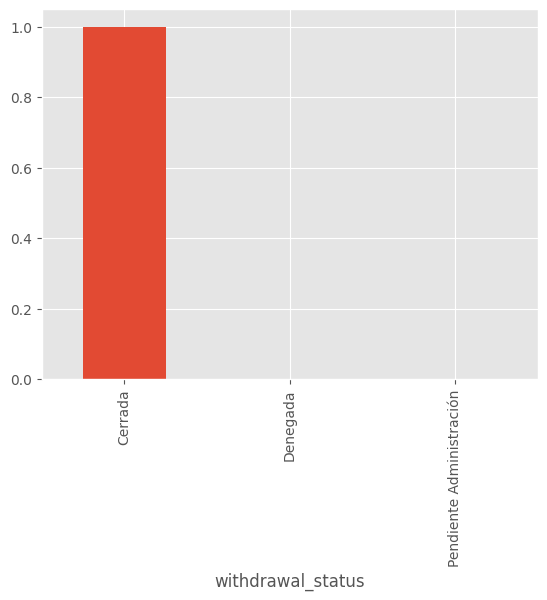

In [19]:
df_wd.withdrawal_status.value_counts(normalize=True).plot(kind='bar')
print(df_wd.withdrawal_status.value_counts(normalize=True))

Pregunta: predomina la categoría "Cerrada" con casi un 99.99%. ¿Habría que eliminarla? Entiendo que no da mucha información ya que el dataset de por sí son los casos en los que la salida del cliente fue definitiva, con lo cual el estado de de "withdrawal" no tiene mucha relevancia aquí

In [20]:
df_wd.withdrawal_type.value_counts(normalize=True)

withdrawal_type
TOTAL      0.92721
PARCIAL    0.07279
Name: proportion, dtype: float64

In [21]:
df_wd.withdrawal_creation_date = df_wd.withdrawal_creation_date.dt.normalize()

<Axes: xlabel='is_definitive_withdrawal'>

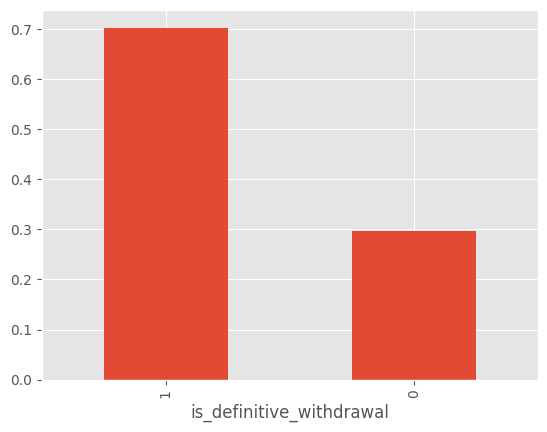

In [22]:
df_wd.is_definitive_withdrawal.value_counts(normalize=True).plot(kind="bar")

In [23]:
df_wd[df_wd.is_definitive_withdrawal == 1]

,withdrawal_id,advertiser_zrive_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal
0,0,259,Cerrada,TOTAL,2012-06-19,2012-07-01,RESULTADOS,1
1,1,221,Cerrada,TOTAL,2012-06-19,NaT,RESULTADOS,1
2,7,492,Cerrada,TOTAL,2012-06-20,2012-07-01,RESULTADOS,1
3,12,481,Cerrada,TOTAL,2012-06-20,2012-07-01,RESULTADOS,1
4,16,457,Cerrada,TOTAL,2012-06-20,2012-07-01,FALTA DE USO/TIEMPO,1
...,...,...,...,...,...,...,...,...
22663,55613,684,Cerrada,TOTAL,2025-05-30,2025-08-01,RATIO RESULTADO-INVERSION,1
22664,55614,251,Cerrada,TOTAL,2025-05-30,2025-08-01,RATIO RESULTADO-INVERSION,1
22665,55615,80,Cerrada,TOTAL,2025-05-30,2025-08-01,RATIO RESULTADO-INVERSION,1
22666,55616,5149,Cerrada,TOTAL,2025-05-30,2025-07-01,MOROSIDAD,1


In [24]:
df_wd.describe()

,withdrawal_id,advertiser_zrive_id,withdrawal_creation_date,withdrawal_effective_date,is_definitive_withdrawal
count,22668.000000,22668.000000,22668,14348,22668.000000
mean,37768.396374,2329.098774,2021-11-25 13:00:55.267337,2022-02-09 22:13:12.863117056,0.703238
min,0.000000,1.000000,2012-06-19 00:00:00,2012-06-28 00:00:00,0.000000
25%,29216.750000,881.000000,2020-03-24 00:00:00,2020-06-01 00:00:00,0.000000
50%,41392.500000,1902.000000,2022-12-12 00:00:00,2023-02-10 00:00:00,1.000000
75%,48760.250000,3515.000000,2024-03-19 00:00:00,2024-05-16 00:00:00,1.000000
max,55617.000000,7026.000000,2025-05-30 00:00:00,2025-12-01 00:00:00,1.000000
std,13864.117631,1752.783975,NaN,NaN,0.456841


En este dataset, creo que no tiene mucho sentido hacer un .describe()

### Dim Advertiser

Contiene información general y descriptiva de los anunciantes de la plataforma.

- 🔑 **advertiser_zive_id**: Identificador único del anunciante.
- **province_id**: Identificador de la provincia del anunciante.
- **advertiser_province**: Nombre de la provincia del anunciante.
- **updated_at**: Fecha y hora de la última actualización de los datos del anunciante.
- **advertiser_group_id**: Identificador del grupo al que pertenece el anunciante, en caso de formar parte de uno.
- **min_start_contrato_date**: Fecha de inicio del primer contrato del anunciante (antigüedad en la plataforma).
- **max_start_contrato_nuevo_date**: Fecha de inicio del último contrato de tipo *nuevo*, si existe. Indica si el anunciante se dio de baja y posteriormente regresó a la plataforma.
- **contrato_churn_date**: Fecha de finalización del último contrato.  
  - Si es **nula**, el anunciante tiene un contrato activo sin fecha de finalización especificada.  
  - Si es **futura**, no implica necesariamente una baja, ya que el contrato puede renovarse automáticamente.

Pregunta: ¿**contrato_churn_date** es futura con respecto a qué? Creo que respecto al period_int (mes de la tabla fct, que es la foto "actual") 



In [25]:
df_dim.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7076 entries, 0 to 7075
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   advertiser_zrive_id            7076 non-null   int64         
 1   province_id                    7076 non-null   int64         
 2   updated_at                     7076 non-null   datetime64[us]
 3   advertiser_province            7076 non-null   object        
 4   advertiser_group_id            1323 non-null   float64       
 5   min_start_contrato_date        7076 non-null   datetime64[ns]
 6   max_start_contrato_nuevo_date  5208 non-null   datetime64[ns]
 7   contrato_churn_date            3894 non-null   datetime64[ns]
dtypes: datetime64[ns](3), datetime64[us](1), float64(1), int64(2), object(1)
memory usage: 442.4+ KB


In [26]:
print_unique(df_dim)

- advertiser_province (52): ['Álava' 'Albacete' 'Alicante' 'Asturias' 'Badajoz' 'Barcelona' 'Burgos'
 'Cáceres' 'Cantabria' 'Castellón' 'Córdoba' 'La Coruña' 'Girona'
 'Granada' 'Guadalajara' 'Huesca' 'Islas Baleares' 'Jaén' 'Lugo' 'Madrid'
 'Málaga' 'Murcia' 'Navarra' 'Pontevedra' 'La Rioja' 'Segovia' 'Sevilla'
 'Teruel' 'Toledo' 'Valencia' 'Valladolid' 'Vizcaya' 'Zaragoza' 'Almería'
 'Ávila' 'Cádiz' 'Ciudad Real' 'Cuenca' 'Guipúzcoa' 'Huelva' 'León'
 'Lleida' 'Orense' 'Palencia' 'Las Palmas' 'Salamanca' 'Soria' 'Tarragona'
 'Tenerife' 'Zamora' 'Ceuta' 'Melilla']


In [27]:
df_dim.isnull().sum()

advertiser_zrive_id                 0
province_id                         0
updated_at                          0
advertiser_province                 0
advertiser_group_id              5753
min_start_contrato_date             0
max_start_contrato_nuevo_date    1868
contrato_churn_date              3182
dtype: int64

Missing values:
- **advertiser_group_id** indica el grupo al que pertenece el anunciante, (Pregunta) ¿esta información es relevante? Hay anunciantes que no pertenecen a ningun grupo
- **max_start_contrato_nuevo_date** indica la fecha en la que un anunciante que se había dado de baja, se volivó a dar de alta. Tiene sentido que haya valores nulos por que habrá casos en los que el anunciante se dió de baja y no volvió. Una cuestión interesante es ver con qué precio se dió de alta tanto la primera como la segunda vez
- **contrato_churn_date** indica la fecha final del último contrato. 

Pregunta: ¿Los valores nulos indican que el contrato está activo?

In [28]:
float(df_dim.max_start_contrato_nuevo_date.isna().sum())/df_dim.shape[0]

0.2639909553420011

In [29]:
df_dim[df_dim["max_start_contrato_nuevo_date"].isna() & df_dim["contrato_churn_date"].isna()]

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date
98,1405,1,2025-06-06 09:54:13,Álava,191.0,2020-04-07,NaT,NaT
104,7026,1,2025-05-14 12:14:57,Álava,NaN,2025-05-14,NaT,NaT
105,2080,1,2024-01-12 15:45:13,Álava,48.0,2020-03-16,NaT,NaT
110,1384,1,2025-03-03 12:31:07,Álava,NaN,2021-04-13,NaT,NaT
111,993,1,2024-01-12 15:00:49,Álava,48.0,2020-03-10,NaT,NaT
...,...,...,...,...,...,...,...,...
3269,2708,50,2024-08-31 11:01:19,Zaragoza,NaN,2021-09-23,NaT,NaT
3271,2310,50,2024-02-28 13:43:30,Zaragoza,NaN,2019-04-01,NaT,NaT
3273,3257,50,2022-11-25 23:18:06,Zaragoza,162.0,2022-05-18,NaT,NaT
3276,2665,50,2024-01-12 15:31:17,Zaragoza,48.0,2020-03-16,NaT,NaT


In [30]:
df_dim[df_dim["max_start_contrato_nuevo_date"].isna() & df_dim["contrato_churn_date"].notna()]

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date
1,6811,1,2025-02-05 01:02:08,Álava,NaN,2025-01-24,NaT,2025-02-04
2,4890,2,2024-08-09 13:38:43,Albacete,133.0,2023-02-24,NaT,2023-06-03
4,547,3,2024-02-05 13:49:02,Alicante,NaN,2023-05-03,NaT,2023-12-29
5,1789,3,2024-11-07 13:26:50,Alicante,185.0,2021-11-15,NaT,2024-11-06
6,5023,3,2024-12-04 11:55:31,Alicante,NaN,2023-04-03,NaT,2023-07-02
...,...,...,...,...,...,...,...,...
7055,5738,29,2024-01-24 13:50:41,Madrid,NaN,2024-01-17,NaT,2025-06-30
7057,1424,30,2024-11-11 12:13:45,Málaga,NaN,2022-09-06,NaT,2025-06-30
7066,2718,42,2024-09-04 16:57:46,Tarragona,NaN,2021-02-01,NaT,2025-06-30
7067,3396,42,2024-12-06 07:25:38,Tarragona,NaN,2022-10-10,NaT,2025-06-30


In [31]:
n_active_contracts = df_dim[df_dim["contrato_churn_date"].isna()]
n_active_contracts

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date
98,1405,1,2025-06-06 09:54:13,Álava,191.0,2020-04-07,NaT,NaT
99,614,1,2025-06-17 13:13:47,Álava,193.0,2022-10-20,2024-02-21,NaT
100,487,1,2024-11-11 13:56:58,Álava,NaN,2023-11-21,2023-11-21,NaT
101,2861,1,2024-08-08 12:14:49,Álava,190.0,2020-04-28,2024-02-28,NaT
102,6703,1,2025-05-19 08:42:47,Álava,125.0,2024-12-20,2024-12-20,NaT
...,...,...,...,...,...,...,...,...
3275,5499,50,2025-02-21 09:12:19,Zaragoza,NaN,2023-10-10,2023-10-10,NaT
3276,2665,50,2024-01-12 15:31:17,Zaragoza,48.0,2020-03-16,NaT,NaT
3277,7073,50,2025-06-17 17:03:47,Zaragoza,NaN,2025-06-17,2025-06-17,NaT
3278,492,50,2025-01-14 12:33:40,Zaragoza,163.0,2022-04-08,NaT,NaT


In [32]:
n_active_contracts.shape[0]/df_dim.shape[0]

0.44968908988128886

Casi el 45% de los contratos están activos a día de hoy

<Axes: xlabel='advertiser_province'>

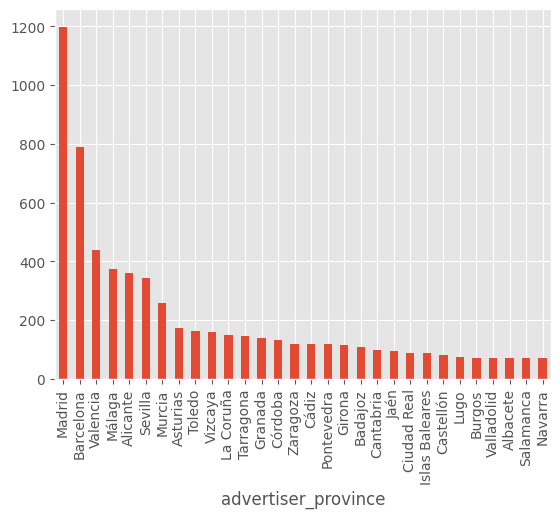

In [33]:
(
    df_dim
    .groupby('advertiser_province')["advertiser_zrive_id"]
    .count()
    .sort_values(ascending=False)
    .head(30)
).plot(kind='bar')

**Outliers**:
- Pocas provincias concentran muchísimos anunciantes 
- Gran mayoría de provincias tienen pocos anunciantes

Pregunta: ¿Debemos transformar esta variable para tratar los outliers?

In [34]:
df_dim['contrato_churn_date'] - df_dim['min_start_contrato_date']

0       130 days
1        11 days
2        99 days
3       229 days
4       240 days
          ...   
7071    280 days
7072   1003 days
7073    482 days
7074    994 days
7075   1075 days
Length: 7076, dtype: timedelta64[ns]

In [35]:
df_dim['contrato_churn_date'] - df_dim['min_start_contrato_date']

0       130 days
1        11 days
2        99 days
3       229 days
4       240 days
          ...   
7071    280 days
7072   1003 days
7073    482 days
7074    994 days
7075   1075 days
Length: 7076, dtype: timedelta64[ns]

Número de días que el anunciante permaneció en la plataforma

In [36]:
df_dim['max_start_contrato_nuevo_date'] - df_dim['min_start_contrato_date']

0        0 days
1           NaT
2           NaT
3        0 days
4           NaT
         ...   
7071     0 days
7072   852 days
7073   323 days
7074     0 days
7075        NaT
Length: 7076, dtype: timedelta64[ns]

In [37]:
df_dim.iloc[7072]

advertiser_zrive_id                              789
province_id                                       48
updated_at                       2025-04-30 13:40:11
advertiser_province                          Vizcaya
advertiser_group_id                              NaN
min_start_contrato_date          2022-10-01 00:00:00
max_start_contrato_nuevo_date    2025-01-30 00:00:00
contrato_churn_date              2025-06-30 00:00:00
Name: 7072, dtype: object

Por ejemplo este anunciante:
- Se dió de alta por primera vez el 2022-10-01
- Se volvió a dar de alta el 2025-01-30
- Se dió de baja el 2025-06-30 (Pregunta: ¿sabemos si se fué antes de que se le acabara el contrato? ¿hay que distinguir entre si se le acabó el contrato y no renovó y si abandonó antes de lo previsto? ¿O ambas casuísticas se tratan igual?)

In [38]:
df_dim.iloc[7075]

advertiser_zrive_id                             4194
province_id                                       50
updated_at                       2023-10-10 11:21:22
advertiser_province                         Zaragoza
advertiser_group_id                              NaN
min_start_contrato_date          2022-07-21 00:00:00
max_start_contrato_nuevo_date                    NaT
contrato_churn_date              2025-06-30 00:00:00
Name: 7075, dtype: object

In [39]:
df_dim.dropna()

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date
0,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17
11,5071,5,2024-05-28 12:02:26,Asturias,156.0,2023-05-16,2023-05-16,2023-12-19
18,2422,8,2024-08-09 09:48:54,Barcelona,41.0,2022-07-19,2022-07-19,2024-06-28
27,1178,9,2019-12-28 20:14:49,Burgos,120.0,2020-02-05,2020-02-05,2024-12-26
31,2210,12,2024-11-14 16:06:14,Cantabria,130.0,2023-06-02,2023-06-02,2024-11-12
...,...,...,...,...,...,...,...,...
6896,5479,46,2025-05-28 11:37:29,Valencia,154.0,2023-11-13,2023-11-13,2025-04-30
6936,6100,11,2025-06-04 14:05:01,Cádiz,184.0,2024-05-27,2024-05-27,2025-05-31
6974,6104,29,2025-06-04 14:11:10,Madrid,184.0,2024-05-28,2024-05-28,2025-05-31
6991,5555,30,2025-06-19 13:22:46,Málaga,159.0,2023-11-07,2023-11-07,2025-05-31


### FCT

Métricas mensuales relacionadas con el desempeño de los anunciantes.

#### Identificadores
- 🔑 **advertiser_zive_id**: Identificador único del anunciante.
- 🔑 **period_int**: Identificador del mes en formato `YYYYMM`.

#### Métricas de anuncios
- **monthly_contracted_ads**: Número total de anuncios contratados.
- **monthly_published_ads**: Número total de anuncios publicados.
- **monthly_unique_published_ads**: Número total de anuncios únicos publicados, en caso de publicar anuncios en diferentes provincias.
- **monthly_distinct_ads**: Número total de anuncios diferentes publicados en un mes (rotación total mensual).

#### Anuncios premium
- **monthly_oro_ads**: Número total de anuncios Oro contratados.
- **monthly_plata_ads**: Número total de anuncios Plata contratados.
- **monthly_destacados_ads**: Número total de anuncios Destacados contratados.
- **monthly_pepitas_ads**: Número total de anuncios Pepitas contratados.

#### Métricas de interacción
- **monthly_shows_ads**: Número total de búsquedas de anuncios publicados.
- **monthly_visits_ads**: Número total de visitas de anuncios publicados.
- **monthly_leads**: Número total de leads de anuncios publicados.
- **monthly_total_phone_views**: Número total de vistas del teléfono del anunciante de anuncios publicados.
- **monthly_total_calls**: Número total de llamadas al anunciante de anuncios publicados.
- **monthly_total_emails**: Número total de emails al anunciante de anuncios publicados.

#### Métricas económicas
- **monthly_total_invoice**: Facturación mensual.
- **monthly_total_reference_price**: Precio tarifa mensual.
- **monthly_avg_ad_price**: Precio medio de los anuncios publicados.

#### Métricas únicas
- **monthly_unique_calls**: Número de llamadas al anunciante de anuncios únicos publicados.
- **monthly_unique_emails**: Número de emails al anunciante de anuncios únicos publicados.
- **monthly_unique_leads**: Número de leads de anuncios únicos publicados.

#### Estado del contrato
- **has_active_contract**: Indica si el anunciante tiene una propuesta activa en el mes.



In [40]:
df_fct = pd.read_parquet(fct_local_path, engine='fastparquet')

In [41]:
df_fct.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96829 entries, 0 to 96828
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   advertiser_zrive_id            96829 non-null  int64  
 1   period_int                     96829 non-null  int64  
 2   monthly_contracted_ads         96829 non-null  int64  
 3   monthly_published_ads          96829 non-null  int64  
 4   monthly_unique_published_ads   96829 non-null  int64  
 5   monthly_distinct_ads           86777 non-null  float64
 6   monthly_oro_ads                96829 non-null  int64  
 7   monthly_plata_ads              96829 non-null  int64  
 8   monthly_destacados_ads         96829 non-null  int64  
 9   monthly_pepitas_ads            96829 non-null  int64  
 10  monthly_shows                  96829 non-null  float64
 11  monthly_visits                 96829 non-null  float64
 12  monthly_leads                  96829 non-null 

In [42]:
df_fct.head()

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_phone_views,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract
0,1,202301,75,47,47,56.0,6,6,6,0,...,14,15,0,1714.2,2416.7,12,3,15,42667.86,True
1,2,202301,150,31,31,55.0,10,10,4,0,...,16,2,2,293.3,3643.3,2,2,4,22742.40,True
2,3,202301,0,0,0,NaN,0,0,0,0,...,0,0,0,0.0,NaN,0,0,0,25420.83,False
3,4,202301,85,79,79,86.0,3,3,1,0,...,10,8,2,1165.0,3023.3,6,6,12,23259.52,True
4,6,202301,20,20,20,25.0,0,0,1,0,...,10,4,3,336.3,515.0,4,11,15,43439.00,True


In [43]:
try:
    df_fct["period_int"] = pd.to_datetime(df_fct['period_int'].astype(str), format="%Y%m")
except ValueError:
    pass
df_fct.head()

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_phone_views,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract
0,1,2023-01-01,75,47,47,56.0,6,6,6,0,...,14,15,0,1714.2,2416.7,12,3,15,42667.86,True
1,2,2023-01-01,150,31,31,55.0,10,10,4,0,...,16,2,2,293.3,3643.3,2,2,4,22742.40,True
2,3,2023-01-01,0,0,0,NaN,0,0,0,0,...,0,0,0,0.0,NaN,0,0,0,25420.83,False
3,4,2023-01-01,85,79,79,86.0,3,3,1,0,...,10,8,2,1165.0,3023.3,6,6,12,23259.52,True
4,6,2023-01-01,20,20,20,25.0,0,0,1,0,...,10,4,3,336.3,515.0,4,11,15,43439.00,True


In [44]:
df_fct.isnull().sum()

advertiser_zrive_id                  0
period_int                           0
monthly_contracted_ads               0
monthly_published_ads                0
monthly_unique_published_ads         0
monthly_distinct_ads             10052
monthly_oro_ads                      0
monthly_plata_ads                    0
monthly_destacados_ads               0
monthly_pepitas_ads                  0
monthly_shows                        0
monthly_visits                       0
monthly_leads                        0
monthly_total_phone_views            0
monthly_total_calls                  0
monthly_total_emails                 0
monthly_total_invoice                0
monthly_total_reference_price    12330
monthly_unique_calls                 0
monthly_unique_emails                0
monthly_unique_leads                 0
monthly_avg_ad_price              8467
has_active_contract                  0
dtype: int64

In [45]:
print_unique(df_fct)

In [46]:
df_fct.head(10)

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_phone_views,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract
0,1,2023-01-01,75,47,47,56.0,6,6,6,0,...,14,15,0,1714.2,2416.7,12,3,15,42667.86,True
1,2,2023-01-01,150,31,31,55.0,10,10,4,0,...,16,2,2,293.3,3643.3,2,2,4,22742.40,True
2,3,2023-01-01,0,0,0,NaN,0,0,0,0,...,0,0,0,0.0,NaN,0,0,0,25420.83,False
3,4,2023-01-01,85,79,79,86.0,3,3,1,0,...,10,8,2,1165.0,3023.3,6,6,12,23259.52,True
4,6,2023-01-01,20,20,20,25.0,0,0,1,0,...,10,4,3,336.3,515.0,4,11,15,43439.00,True
5,7,2023-01-01,50,42,42,49.0,1,1,1,0,...,18,5,3,763.3,1006.7,4,7,11,19495.74,True
6,10,2023-01-01,49,37,37,56.0,11,5,8,0,...,8,3,0,75.0,1645.0,3,3,6,37954.00,True
7,11,2023-01-01,85,6,6,7.0,0,0,0,0,...,1,1,1,150.2,NaN,1,1,2,45955.71,True
8,12,2023-01-01,125,102,102,148.0,21,21,8,0,...,17,7,1,374.9,6855.0,5,3,8,43456.25,True
9,15,2023-01-01,150,112,112,328.0,10,10,4,0,...,24,13,5,1101.7,NaN,10,9,19,16965.04,True


In [47]:
df_fct["advertiser_zrive_id"].nunique()

6968

En la base de datos tenemos información de **6968** anunciantes distintos

In [48]:
df_dim["advertiser_zrive_id"].nunique()

7076

In [49]:
ids_df1 = set(df_fct['advertiser_zrive_id'])
ids_df2 = set(df_dim['advertiser_zrive_id'])

solo_en_df1 = ids_df1 - ids_df2
solo_en_df2 = ids_df2 - ids_df1

df_dim[df_dim['advertiser_zrive_id'].isin(solo_en_df2)]


,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date
12,3388,5,2022-10-28 13:28:56,Asturias,NaN,2024-03-11,NaT,2024-03-15
16,4095,8,2022-10-07 09:43:18,Barcelona,NaN,2022-07-01,NaT,2024-06-27
27,1178,9,2019-12-28 20:14:49,Burgos,120.0,2020-02-05,2020-02-05,2024-12-26
201,7070,3,2025-06-11 15:42:23,Alicante,NaN,2025-06-11,2025-06-11,NaT
240,6918,3,2025-06-18 13:01:44,Alicante,NaN,2025-06-11,2025-06-11,NaT
...,...,...,...,...,...,...,...,...
6633,1800,9,2019-12-28 19:59:58,Burgos,120.0,2024-07-29,2024-07-29,2025-03-31
6642,2662,12,2021-01-21 12:17:37,Cantabria,NaN,2024-06-07,2024-06-07,2025-03-31
6708,545,30,2021-01-21 12:21:40,Málaga,NaN,2024-06-03,2024-06-03,2025-03-31
7009,2351,40,2022-10-28 10:07:04,Sevilla,NaN,2020-11-11,2020-11-11,2025-05-31


In [50]:
df_dim.advertiser_group_id.nunique()

112

Hay 112 grupos de anunciantes

<Axes: title={'center': 'Top 10 grupos con más anunciantes'}, xlabel='advertiser_group_id'>

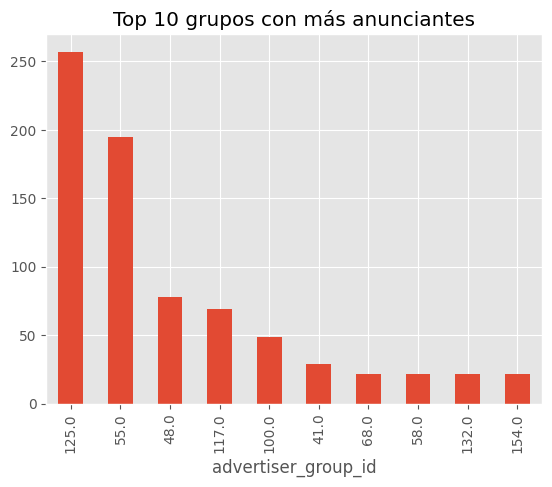

In [51]:
advertiser_groups = (
    df_dim
    .groupby("advertiser_group_id")["advertiser_zrive_id"]
    .nunique()
    .sort_values(ascending=False)
)
advertiser_groups.head(10).plot(kind='bar', title="Top 10 grupos con más anunciantes")

In [52]:
advertiser_groups.describe()

count    112.000000
mean      11.812500
std       31.438924
min        1.000000
25%        2.000000
50%        4.000000
75%       11.000000
max      257.000000
Name: advertiser_zrive_id, dtype: float64

<Axes: >

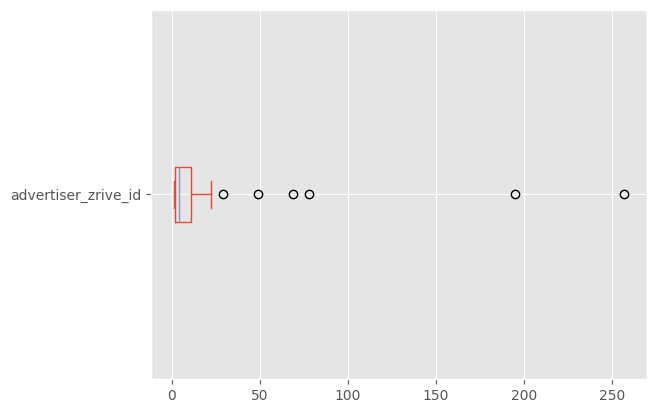

In [53]:
advertiser_groups.plot(kind='box', vert=False)

#### Merge 

Hacemos un left join en **Zrive_fct_monthly_snapshot_advertiser (df_fct)** para tener la foto completa con la información de **Zrive_dim_advertiser (df_dim)**

In [54]:
df_fct_merged = df_fct.merge(right=df_dim, how='left', on='advertiser_zrive_id')

<Axes: title={'center': 'Usuarios con grupo vs. individuales'}, xlabel='advertiser_group_id'>

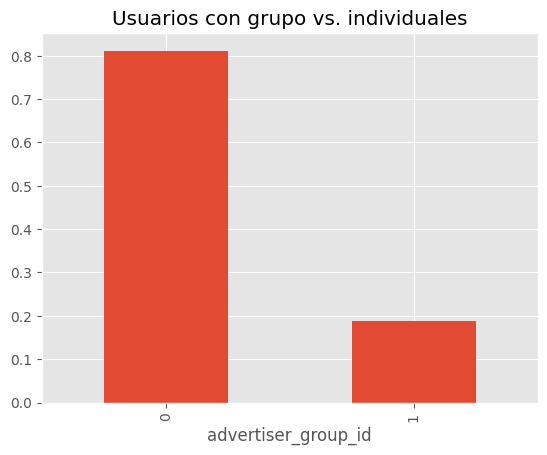

In [55]:
# Proporción de anunciantes pertenecientes a un grupo y anunciantes individuales

advertiser_group_proportion = (
    df_fct_merged
    .groupby("advertiser_zrive_id")["advertiser_group_id"]
    .nunique()
)

advertiser_group_proportion.value_counts(normalize=True).plot(kind='bar', title="Usuarios con grupo vs. individuales")

In [56]:
print(f"% advertisers pertenecientes a grupos: {advertiser_group_proportion.value_counts()[0]/advertiser_group_proportion.shape[0]:.4f}")
print(f"% advertisers pertenecientes a grupos: {advertiser_group_proportion.value_counts()[1]/advertiser_group_proportion.shape[0]:.4f}")

% advertisers pertenecientes a grupos: 0.8117
% advertisers pertenecientes a grupos: 0.1883


In [57]:
advertiser_group_proportion.value_counts()[0]

np.int64(5656)

In [58]:
print(df_fct_merged["period_int"].min())
print(df_fct_merged["period_int"].max())

2023-01-01 00:00:00
2025-05-01 00:00:00


El período del que se tienen datos va desde el 2023-01 hasta 2025-05

In [59]:
df_fct_merged[["period_int", "advertiser_zrive_id"]].isna().sum()

period_int             0
advertiser_zrive_id    0
dtype: int64

In [60]:
df_fct_merged.head()

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_unique_leads,monthly_avg_ad_price,has_active_contract,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date
0,1,2023-01-01,75,47,47,56.0,6,6,6,0,...,15,42667.86,True,11,2023-06-16 09:35:01,Cádiz,NaN,2020-12-23,NaT,2023-05-31
1,2,2023-01-01,150,31,31,55.0,10,10,4,0,...,4,22742.40,True,11,2023-11-06 16:01:14,Cádiz,100.0,2020-09-25,2020-09-25,NaT
2,3,2023-01-01,0,0,0,NaN,0,0,0,0,...,0,25420.83,False,8,2024-08-07 13:37:09,Barcelona,41.0,2024-05-06,NaT,2024-07-15
3,4,2023-01-01,85,79,79,86.0,3,3,1,0,...,12,23259.52,True,48,2023-05-03 16:37:02,Vizcaya,NaN,2022-09-30,NaT,NaT
4,6,2023-01-01,20,20,20,25.0,0,0,1,0,...,15,43439.00,True,48,2025-03-12 13:48:02,Vizcaya,NaN,2022-10-10,NaT,NaT


In [61]:
df_fct_merged[df_fct_merged["advertiser_zrive_id"] == 1]


,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_unique_leads,monthly_avg_ad_price,has_active_contract,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date
0,1,2023-01-01,75,47,47,56.0,6,6,6,0,...,15,42667.86,True,11,2023-06-16 09:35:01,Cádiz,NaN,2020-12-23,NaT,2023-05-31
3542,1,2023-02-01,50,44,44,48.0,3,3,1,0,...,9,42691.67,True,11,2023-06-16 09:35:01,Cádiz,NaN,2020-12-23,NaT,2023-05-31
6905,1,2023-03-01,50,39,39,48.0,3,3,1,0,...,6,44193.75,True,11,2023-06-16 09:35:01,Cádiz,NaN,2020-12-23,NaT,2023-05-31
10328,1,2023-04-01,50,39,39,40.0,3,3,1,0,...,6,44452.50,True,11,2023-06-16 09:35:01,Cádiz,NaN,2020-12-23,NaT,2023-05-31
13747,1,2023-05-01,150,0,0,39.0,0,3,1,0,...,8,43033.33,True,11,2023-06-16 09:35:01,Cádiz,NaN,2020-12-23,NaT,2023-05-31


#### Merge completo

Se hace un **LEFT JOIN** para tener la foto completa

- df_fct
- df_dim
- df_wd

In [62]:
df_full = df_fct_merged.merge(right=df_wd, how='left', on='advertiser_zrive_id')

In [63]:
df_full

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal
0,1,2023-01-01,75,47,47,56.0,6,6,6,0,...,2020-12-23,NaT,2023-05-31,6733.0,Cerrada,TOTAL,2015-12-10,NaT,FALTA DE USO/TIEMPO,1.0
1,1,2023-01-01,75,47,47,56.0,6,6,6,0,...,2020-12-23,NaT,2023-05-31,22987.0,Cerrada,PARCIAL,2018-09-27,2018-10-01,FALTA DE PRODUCTO,0.0
2,1,2023-01-01,75,47,47,56.0,6,6,6,0,...,2020-12-23,NaT,2023-05-31,23384.0,Cerrada,PARCIAL,2018-12-03,2018-12-01,RAZONES ECONOMICAS,0.0
3,1,2023-01-01,75,47,47,56.0,6,6,6,0,...,2020-12-23,NaT,2023-05-31,33451.0,Cerrada,TOTAL,2020-12-23,2020-12-28,Cambio a Bundle Online,0.0
4,1,2023-01-01,75,47,47,56.0,6,6,6,0,...,2020-12-23,NaT,2023-05-31,35720.0,Cerrada,TOTAL,2021-07-09,2021-07-30,Cambio de Contrato/propuesta/producto,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407656,7047,2025-05-01,3,0,0,NaN,0,0,2,0,...,2025-05-28,2025-05-28,NaT,NaN,NaN,NaN,NaT,NaT,NaN,NaN
407657,7051,2025-05-01,20,0,0,NaN,0,0,0,0,...,2025-05-29,2025-05-29,NaT,NaN,NaN,NaN,NaT,NaT,NaN,NaN
407658,7052,2025-05-01,3,0,0,NaN,0,0,2,0,...,2025-05-29,2025-05-29,NaT,NaN,NaN,NaN,NaT,NaT,NaN,NaN
407659,7066,2025-05-01,20,20,20,29.0,3,3,7,0,...,2025-06-10,NaT,NaT,NaN,NaN,NaN,NaT,NaT,NaN,NaN


In [64]:

print(df_full[df_full["advertiser_zrive_id"] == 1]["withdrawal_id"].nunique())
print(df_full[df_full["advertiser_zrive_id"] == 1]["period_int"].nunique())


7
5


Comportamiento usuarios: usuario(advertiser_zrive_id) = 1:
- Solicitó una baja **7** veces
- Estuvo en la plataforma durante **5 meses**

In [65]:
df_full[df_full["advertiser_zrive_id"] == 1]["min_start_contrato_date"].max()

Timestamp('2020-12-23 00:00:00')

In [66]:
(
    df_full[df_full["advertiser_zrive_id"] == 1]
    ["min_start_contrato_date"]
    .nunique()
)

1

In [67]:
(
    df_full
    .groupby("advertiser_zrive_id")["max_start_contrato_nuevo_date"]
    .nunique()
    .eq(1)
    .sum()
)

np.int64(5123)

Hay **5123** advertisers que se dieron de baja y volvieron al menos 1 vez

In [68]:
(
    df_full
    .groupby("advertiser_zrive_id")["min_start_contrato_date"]
    .nunique()
    .eq(1)
    .sum()
)

np.int64(6968)

Todos los advertisers tienen 1 fecha de contrato

In [69]:
(
    df_full
    .groupby("advertiser_zrive_id")["period_int"]
    .nunique()
    .lt(3)
)

advertiser_zrive_id
1       False
2       False
3       False
4       False
5       False
        ...  
7047     True
7051     True
7052     True
7066    False
7069     True
Name: period_int, Length: 6968, dtype: bool

Sólo **571 advertisers** permanecieron menos de 3 meses en la plataforma

In [70]:
mask = (
    df_full
    .groupby("advertiser_zrive_id")["period_int"]
    .nunique()
    .lt(3)
)

df_full[df_full["advertiser_zrive_id"].map(mask)]


,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal
241,46,2023-01-01,100,100,100,119.0,2,2,2,0,...,2021-04-23,NaT,2023-01-31,35197.0,Cerrada,TOTAL,2021-05-20,2021-05-20,OTROS,1.0
242,46,2023-01-01,100,100,100,119.0,2,2,2,0,...,2021-04-23,NaT,2023-01-31,42271.0,Cerrada,TOTAL,2023-01-31,2023-02-01,RESULTADOS,1.0
798,142,2023-01-01,35,35,35,54.0,3,2,2,0,...,2022-07-22,2022-07-22,2023-01-31,5728.0,Cerrada,PARCIAL,2015-06-30,2015-07-01,FIN DE CONTRATO,0.0
799,142,2023-01-01,35,35,35,54.0,3,2,2,0,...,2022-07-22,2022-07-22,2023-01-31,6864.0,Cerrada,TOTAL,2016-01-04,2016-01-01,FALTA DE USO/TIEMPO,1.0
800,142,2023-01-01,35,35,35,54.0,3,2,2,0,...,2022-07-22,2022-07-22,2023-01-31,24953.0,Cerrada,TOTAL,2019-05-06,2019-06-01,RESULTADOS,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407654,7045,2025-05-01,3,0,0,NaN,0,0,2,0,...,2025-05-29,2025-05-29,NaT,NaN,NaN,NaN,NaT,NaT,NaN,NaN
407656,7047,2025-05-01,3,0,0,NaN,0,0,2,0,...,2025-05-28,2025-05-28,NaT,NaN,NaN,NaN,NaT,NaT,NaN,NaN
407657,7051,2025-05-01,20,0,0,NaN,0,0,0,0,...,2025-05-29,2025-05-29,NaT,NaN,NaN,NaN,NaT,NaT,NaN,NaN
407658,7052,2025-05-01,3,0,0,NaN,0,0,2,0,...,2025-05-29,2025-05-29,NaT,NaN,NaN,NaN,NaT,NaT,NaN,NaN


In [71]:
df_full[df_full["advertiser_zrive_id"] == 1].groupby("withdrawal_id")["withdrawal_reason"].nunique()

withdrawal_id
6733.0     1
22987.0    1
23384.0    1
33451.0    1
35720.0    1
40999.0    1
43036.0    1
Name: withdrawal_reason, dtype: int64

In [72]:
df_full.head(5)

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal
0,1,2023-01-01,75,47,47,56.0,6,6,6,0,...,2020-12-23,NaT,2023-05-31,6733.0,Cerrada,TOTAL,2015-12-10,NaT,FALTA DE USO/TIEMPO,1.0
1,1,2023-01-01,75,47,47,56.0,6,6,6,0,...,2020-12-23,NaT,2023-05-31,22987.0,Cerrada,PARCIAL,2018-09-27,2018-10-01,FALTA DE PRODUCTO,0.0
2,1,2023-01-01,75,47,47,56.0,6,6,6,0,...,2020-12-23,NaT,2023-05-31,23384.0,Cerrada,PARCIAL,2018-12-03,2018-12-01,RAZONES ECONOMICAS,0.0
3,1,2023-01-01,75,47,47,56.0,6,6,6,0,...,2020-12-23,NaT,2023-05-31,33451.0,Cerrada,TOTAL,2020-12-23,2020-12-28,Cambio a Bundle Online,0.0
4,1,2023-01-01,75,47,47,56.0,6,6,6,0,...,2020-12-23,NaT,2023-05-31,35720.0,Cerrada,TOTAL,2021-07-09,2021-07-30,Cambio de Contrato/propuesta/producto,0.0


### Análisis permanencia por anunciante

In [73]:
df_months = (
    df_full
    .groupby("advertiser_zrive_id")["period_int"]
    .nunique()
    .reset_index()
    .rename(columns={"period_int":"n_months"})
)

print(df_months["n_months"].describe())

count    6968.000000
mean       13.896240
std         9.970446
min         1.000000
25%         5.000000
50%        11.000000
75%        25.000000
max        29.000000
Name: n_months, dtype: float64


Text(0, 0.5, 'Anunciantes')

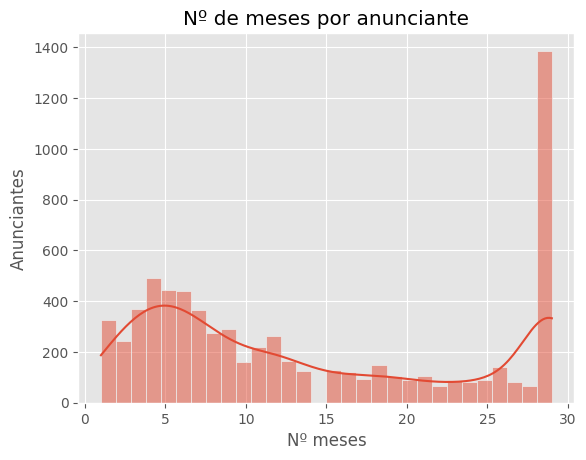

In [74]:
sns.histplot(df_months, x="n_months", bins=30, kde=True)

plt.title("Nº de meses por anunciante")
plt.xlabel("Nº meses")
plt.ylabel("Anunciantes")

Text(0.5, 1.0, 'Distribución de n_months')

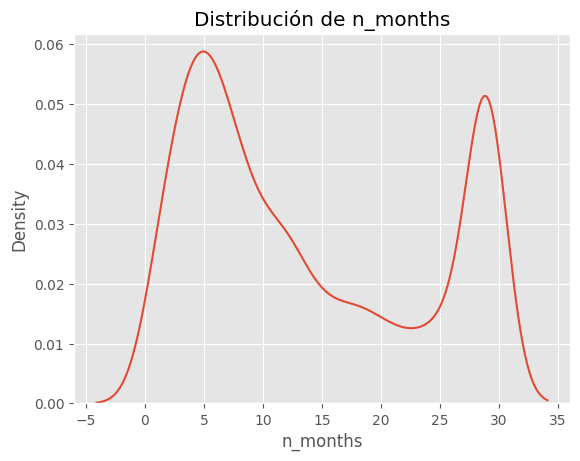

In [75]:
sns.kdeplot(df_months["n_months"])
plt.title("Distribución de n_months")

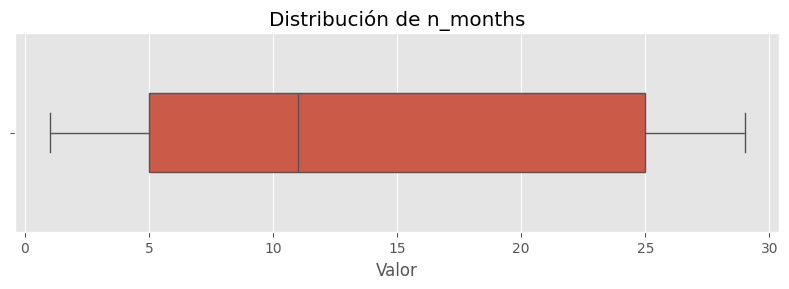

In [76]:
plt.figure(figsize=(8,3))

ax = sns.boxplot(
    data=df_months,
    x="n_months",
    width=0.4,
    showfliers=False
)

ax.set_title("Distribución de n_months")
ax.set_xlabel("Valor")
plt.tight_layout()

Text(0.5, 1.0, 'Distribución de n_months < 29')

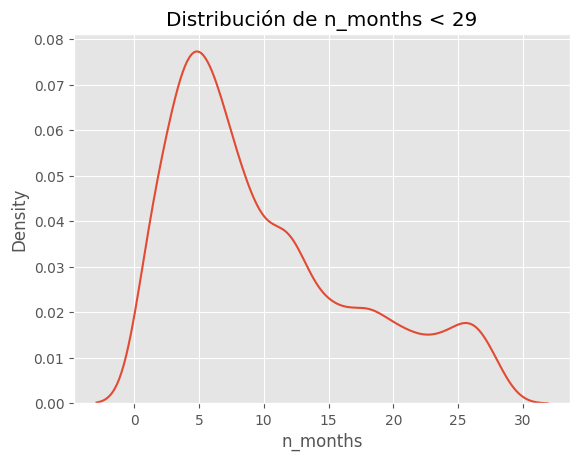

In [77]:
sns.kdeplot(df_months[df_months["n_months"] < 29]["n_months"])
plt.title("Distribución de n_months < 29")

In [78]:
df_months[df_months["n_months"] == 29].count()

advertiser_zrive_id    1387
n_months               1387
dtype: int64

In [79]:
long_term_adv_pct = len(df_months[df_months["n_months"] == 29])/len(df_months)*100
round(long_term_adv_pct,2)

19.91

De aquí podemos sacar insights:
- Los anunciantes permanecen en la plataforma una media de 13.9 meses
- Ditribución bimodal; dos poblaciones: 
    - Anunciantes corto-medio plazo, muchos se concentran a la izquierda, permaneciendo pocos meses activos
    - Anunciantes largo plazo: un total de **1387** anunciantes (casi un 20%) permanecieron el periodo completo (29 meses)
- Si quitamos anunciantes que permanecieron 29 meses, obtenemos la gráfica anterior

### Análisis **estabilidad**

count    6968.000000
mean        0.918054
std         0.274302
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: is_stable, dtype: float64


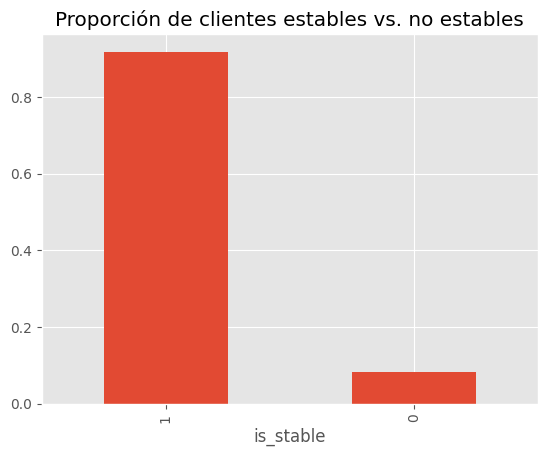

In [80]:
df_advertiser = (
    df_full.groupby("advertiser_zrive_id")["period_int"]
    .nunique()
    .reset_index()
    .assign(is_stable=lambda df: (df["period_int"] >= 3).astype(int))
)
df_advertiser.is_stable.value_counts(normalize=True).plot(kind='bar')
plt.title("Proporción de clientes estables vs. no estables")

print(df_advertiser.is_stable.describe())

Si definimos un cliente **no estable** como un cliente que permaneció en la plataforma **menos de 3 meses**, obtenemos esta gráfica que representa la distribución de clientes por estabilidad.
Observamos que está bastante desbalanceada, es decir, la mayoría de advertisers permanecieron más de 3 meses

### Análisis de los clientes **No Estables**

In [81]:
unstable_ids = df_advertiser.loc[df_advertiser["is_stable"] == 0, "advertiser_zrive_id"]

In [82]:
df_unstable = df_full[df_full["advertiser_zrive_id"].isin(unstable_ids)]
# df_unstable.head(20)

Ejemplo: usuario 142
- No estable: period_int únicos = 1 (solo permaneció 1 mes)
- Tiene 6 withdrawal_id diferentes: solicitó la baja en **6 ocasiones**
- Se dió de baja definitivamente ("is_definite_withdrawal") **5 veces**


## **LATEST approach**

Sabemos que un usuario es churn si:
1. withdrawal_type = 'TOTAL'
2. withdrawal_status != 'Denegada'
3. withdrawal_reason not in ('Upselling-cambio de contrato', 'Cambio a Bundle Online',
'Cambio de Contrato/propuesta/producto')

Por otro lado, de la tabla **zrive_dim_advertiser** tenemos los siguientes datos:
- **min_start_contrato_date**: primera: fecha inicio primer contrato (nuevo contrato)
- **max_start_contrato_nuevo_date**: última fecha de inicio de nuevo contrato
- **contrato_churn_date**: fecha fin de contrato

Según estas definiciones:

**duración del contrato** = end_date - max(max_start_contrato_nuevo_date, min_start_contrato_date)

**end_date** se define más abajo mediante una lógica


Para este approach, vamos a analizar el dataset de información general de los advertisers en la plataforma (df_dim) junto con el comportamiento de withdrawals (df_wd)

In [83]:
dim_ids = set(df_dim.advertiser_zrive_id.unique())
wd_ids = set(df_wd.advertiser_zrive_id.unique())
dim_surplus = dim_ids - wd_ids
len(dim_surplus)

1055

Hay 1055 advertisers de los que no se tiene información sobre withdrawals. Esto es, de los **7076** advertisers, sólo hay información de withdrawal de **6021** de ellos.

Hacemos un **LEFT JOIN** entre las dos tablas, y observamos los registros que no tienen información sobre **withdrawals**

In [84]:
df_dim_wd = df_dim.merge(right=df_wd, how='left')
# df_dim_wd[df_dim_wd["withdrawal_id"].isna() & (df_dim_wd["is_active"] == 1)]

Ahora, vamos a crear una nueva columna donde calculamos el tiempo de permanencia en la plataforma (meses). Para ello vamos a realizar la siguiente operación:

$$
T^\circ_{\text{permanencia}} =
\text{end\_date}
-
\max(\text{max\_start\_contrato\_nuevo\_date},
     \text{min\_start\_contrato\_date})
$$

### Fecha de alta: **start_date**

Será la fecha más reciente del comienzo de un contrato, es decir:

    máx("max_start_contrato_nuevo_date", "min_start_contrato_date")

In [85]:
# start_date = df_dim_wd[["max_start_contrato_nuevo_date", "min_start_contrato_date"]].max(axis=1)

df_dim_wd["start_date"] = df_dim_wd[["max_start_contrato_nuevo_date", "min_start_contrato_date"]].max(axis=1)
df_dim_wd["start_date"] = pd.to_datetime(df_dim_wd["start_date"])

df_dim_wd["snapshot_date"] = df_dim_wd["updated_at"]
df_dim_wd["snapshot_date"] = pd.to_datetime(df_dim_wd["snapshot_date"]).dt.date
            
df_dim_wd 

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal,start_date,snapshot_date
0,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,4758.0,Cerrada,TOTAL,2015-01-16,2015-03-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01
1,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,23029.0,Cerrada,TOTAL,2018-10-08,2018-11-01,RESULTADOS,1.0,2025-01-07,2025-05-01
2,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,32827.0,Cerrada,TOTAL,2020-11-17,2020-11-20,Cambio a Bundle Online,0.0,2025-01-07,2025-05-01
3,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,33518.0,Cerrada,TOTAL,2021-01-05,2021-02-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01
4,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,54519.0,Cerrada,TOTAL,2025-03-18,2025-05-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23718,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,46264.0,Cerrada,TOTAL,2023-10-09,2023-10-09,Cambio de Contrato/propuesta/producto,0.0,2022-07-21,2023-10-10
23719,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,47376.0,Cerrada,TOTAL,2023-12-21,NaT,FALTA DE USO/TIEMPO,1.0,2022-07-21,2023-10-10
23720,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,48614.0,Cerrada,TOTAL,2024-03-12,NaT,RAZONES ECONOMICAS,1.0,2022-07-21,2023-10-10
23721,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,51090.0,Cerrada,TOTAL,2024-08-29,NaT,RESULTADOS,1.0,2022-07-21,2023-10-10


In [86]:
df_dim_wd[df_dim_wd["updated_at"]<(df_dim_wd["withdrawal_effective_date"]-pd.Timedelta(days=90))]

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal,start_date,snapshot_date
90,1178,9,2019-12-28 20:14:49,Burgos,120.0,2020-02-05,2020-02-05,2024-12-26,43272.0,Cerrada,TOTAL,2023-03-30,2023-04-01,RESULTADOS,1.0,2020-02-05,2019-12-28
91,1178,9,2019-12-28 20:14:49,Burgos,120.0,2020-02-05,2020-02-05,2024-12-26,52509.0,Cerrada,TOTAL,2024-11-18,2025-01-01,RESULTADOS,1.0,2020-02-05,2019-12-28
285,7026,1,2025-05-14 12:14:57,Álava,NaN,2025-05-14,NaT,NaT,55418.0,Cerrada,TOTAL,2025-05-16,2025-12-01,RESULTADOS,1.0,2025-05-14,2025-05-14
356,1967,2,2022-12-21 10:46:18,Albacete,NaN,2022-12-13,NaT,NaT,47579.0,Cerrada,TOTAL,2024-01-15,2024-02-01,Cambio de Contrato/propuesta/producto,0.0,2022-12-13,2022-12-21
357,1967,2,2022-12-21 10:46:18,Albacete,NaN,2022-12-13,NaT,NaT,48562.0,Cerrada,TOTAL,2024-03-11,2024-03-11,Upselling-cambio de contrato,0.0,2022-12-13,2022-12-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23673,2718,42,2024-09-04 16:57:46,Tarragona,NaN,2021-02-01,NaT,2025-06-30,55336.0,Cerrada,TOTAL,2025-05-12,2025-07-01,FALTA DE USO/TIEMPO,1.0,2021-02-01,2024-09-04
23681,3396,42,2024-12-06 07:25:38,Tarragona,NaN,2022-10-10,NaT,2025-06-30,55335.0,Cerrada,TOTAL,2025-05-12,2025-07-01,FALTA DE USO/TIEMPO,1.0,2022-10-10,2024-12-06
23683,2970,45,2025-01-17 12:08:18,Toledo,NaN,2022-08-01,2024-10-17,2025-06-30,55308.0,Cerrada,TOTAL,2025-05-09,2025-07-01,CESE DE ACTIVIDAD,1.0,2024-10-17,2025-01-17
23691,3166,46,2025-02-27 14:21:20,Valencia,NaN,2021-05-14,2024-11-27,2025-06-30,55149.0,Cerrada,TOTAL,2025-04-25,2025-07-01,FALTA DE USO/TIEMPO,1.0,2024-11-27,2025-02-27


### Fecha de baja: **end_date**

Para que la fecha de churn sea **withdrawal_effective_date** se deben cumplir simultáneamnete las siguientes condiciones:
- Que **is_definitive_withdrawal = 1**
- Que **withdrawal_effective_date** != NaT
- Que **withdrawal_effective_date** > **start_date**
- Que **contrato_churn_date** = NaT ó que sea más tarde que **withdrawal_effective_date**
- Que **withdrawal_effective_date** sea menor que **snapshot_date** (para no incurrir en **data leakage**)

Si no, habría dos escenarios:
- **contrato_churn_date** != NaT y menor que **snapshot_date** : 
-> Fecha de churn = **contrato_churn_date**

Y si no:
- Fecha de churn = **snapshot_date**


In [87]:
df_dim_wd


,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal,start_date,snapshot_date
0,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,4758.0,Cerrada,TOTAL,2015-01-16,2015-03-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01
1,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,23029.0,Cerrada,TOTAL,2018-10-08,2018-11-01,RESULTADOS,1.0,2025-01-07,2025-05-01
2,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,32827.0,Cerrada,TOTAL,2020-11-17,2020-11-20,Cambio a Bundle Online,0.0,2025-01-07,2025-05-01
3,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,33518.0,Cerrada,TOTAL,2021-01-05,2021-02-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01
4,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,54519.0,Cerrada,TOTAL,2025-03-18,2025-05-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23718,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,46264.0,Cerrada,TOTAL,2023-10-09,2023-10-09,Cambio de Contrato/propuesta/producto,0.0,2022-07-21,2023-10-10
23719,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,47376.0,Cerrada,TOTAL,2023-12-21,NaT,FALTA DE USO/TIEMPO,1.0,2022-07-21,2023-10-10
23720,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,48614.0,Cerrada,TOTAL,2024-03-12,NaT,RAZONES ECONOMICAS,1.0,2022-07-21,2023-10-10
23721,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,51090.0,Cerrada,TOTAL,2024-08-29,NaT,RESULTADOS,1.0,2022-07-21,2023-10-10


### ¿Cuál es realmente la fecha de fin de permanencia **end_date**?

- Si hay baja definitiva anticipada y observable antes del snapshot → **end_date = withdrawal_effective_date**
- Si no hay baja anticipada pero sí fin de contrato observable → **end_date = contrato_churn_date**
- Si ninguna de las anteriores → censurado → **end_date = snapshot_date** (Esto significa que no hay fecha anterior a la fecha última en la que se tomaron los datos, con lo cual se corta en snapshot_date = usuario activo)

In [88]:
# CASO 1:
# Hay withdrawal definitivo y ocurre antes que fecha fin de contrato (o no hay fecha fin de contrato)
mask_withdrawal = (
    (df_dim_wd["is_definitive_withdrawal"] == 1) & # debe ser una baja DEFINITIVA
    (df_dim_wd["withdrawal_effective_date"].notna()) & # tiene que existir
    (df_dim_wd["withdrawal_effective_date"] > df_dim_wd["start_date"]) & # la fecha de comienzo de contrato debe ser, lógicamente, menor que la fecha de withdrawal
    (
        df_dim_wd["contrato_churn_date"].isna() | 
        (df_dim_wd["withdrawal_effective_date"] < df_dim_wd["contrato_churn_date"]) # No hay fecha fin de contrato o ésta es mayor a la withdrawal ==> se dió de baja antes de fecha fin de contrato
    ) & 
    (df_dim_wd["withdrawal_effective_date"] < df_dim_wd["snapshot_date"]) # Debe ser anterior a la fecha de snapshot (última fecha de actualización de ese advertiser)
)

# CASO 2: 
# No hay ruptura anticipada, pero hay fin de contrato observable
mask_contract_end = (
        (df_dim_wd["contrato_churn_date"].notna()) &
        (df_dim_wd["contrato_churn_date"] < df_dim_wd["snapshot_date"])
)

df_dim_wd["end_date"] = np.select(
    condlist=[
        mask_withdrawal, 
        mask_contract_end
    ],
    choicelist=[
        df_dim_wd["withdrawal_effective_date"],
        df_dim_wd["contrato_churn_date"]
    ],
    default=df_dim_wd["snapshot_date"] # Si no se cumple ninguna condición, se toma la fecha final como la última fecha de actualización de los datos
)
df_dim_wd["end_date"] = pd.to_datetime(df_dim_wd["end_date"])

# Nos quedamos únicamente con los registros donde updated_at > start_date
df_dim_wd = df_dim_wd.loc[df_dim_wd["updated_at"] > df_dim_wd["start_date"]]



### Días de permanencia

In [89]:
df_dim_wd["permanencia"] = (df_dim_wd["end_date"] - df_dim_wd["start_date"])


/tmp/ipykernel_2958/2279193302.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dim_wd["permanencia"] = (df_dim_wd["end_date"] - df_dim_wd["start_date"])


In [90]:
df_dim_wd["dias_permanencia"] = df_dim_wd["permanencia"].dt.days
df_dim_wd.head()

/tmp/ipykernel_2958/2122577522.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dim_wd["dias_permanencia"] = df_dim_wd["permanencia"].dt.days


,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal,start_date,snapshot_date,end_date,permanencia,dias_permanencia
0,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,4758.0,Cerrada,TOTAL,2015-01-16,2015-03-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114
1,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,23029.0,Cerrada,TOTAL,2018-10-08,2018-11-01,RESULTADOS,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114
2,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,32827.0,Cerrada,TOTAL,2020-11-17,2020-11-20,Cambio a Bundle Online,0.0,2025-01-07,2025-05-01,2025-05-01,114 days,114
3,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,33518.0,Cerrada,TOTAL,2021-01-05,2021-02-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114
4,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,54519.0,Cerrada,TOTAL,2025-03-18,2025-05-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114


In [91]:
df_dim_wd["dias_permanencia"].describe()

count    23568.000000
mean       585.566870
std        535.197471
min          0.000000
25%        159.000000
50%        407.000000
75%        910.000000
max       5169.000000
Name: dias_permanencia, dtype: float64

Para continuar el análisis, nos quedamos con las columnas siguientes

In [92]:
df_churn = df_dim_wd.copy()
withdrawal_cols = [
    "advertiser_zrive_id",
    "advertiser_group_id", 
    "province_id", 
    "min_start_contrato_date", 
    "max_start_contrato_nuevo_date", 
    "contrato_churn_date",
    "withdrawal_id",
    "withdrawal_creation_date",
    "withdrawal_effective_date", 
    "is_definitive_withdrawal",  
    "start_date", 
    "snapshot_date", 
    "end_date", 
    "dias_permanencia"
    ]
df_churn = df_churn[withdrawal_cols]
df_churn

,advertiser_zrive_id,advertiser_group_id,province_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_creation_date,withdrawal_effective_date,is_definitive_withdrawal,start_date,snapshot_date,end_date,dias_permanencia
0,986,194.0,1,2025-01-07,2025-01-07,2025-05-17,4758.0,2015-01-16,2015-03-01,1.0,2025-01-07,2025-05-01,2025-05-01,114
1,986,194.0,1,2025-01-07,2025-01-07,2025-05-17,23029.0,2018-10-08,2018-11-01,1.0,2025-01-07,2025-05-01,2025-05-01,114
2,986,194.0,1,2025-01-07,2025-01-07,2025-05-17,32827.0,2020-11-17,2020-11-20,0.0,2025-01-07,2025-05-01,2025-05-01,114
3,986,194.0,1,2025-01-07,2025-01-07,2025-05-17,33518.0,2021-01-05,2021-02-01,1.0,2025-01-07,2025-05-01,2025-05-01,114
4,986,194.0,1,2025-01-07,2025-01-07,2025-05-17,54519.0,2025-03-18,2025-05-01,1.0,2025-01-07,2025-05-01,2025-05-01,114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23718,4194,NaN,50,2022-07-21,NaT,2025-06-30,46264.0,2023-10-09,2023-10-09,0.0,2022-07-21,2023-10-10,2023-10-10,446
23719,4194,NaN,50,2022-07-21,NaT,2025-06-30,47376.0,2023-12-21,NaT,1.0,2022-07-21,2023-10-10,2023-10-10,446
23720,4194,NaN,50,2022-07-21,NaT,2025-06-30,48614.0,2024-03-12,NaT,1.0,2022-07-21,2023-10-10,2023-10-10,446
23721,4194,NaN,50,2022-07-21,NaT,2025-06-30,51090.0,2024-08-29,NaT,1.0,2022-07-21,2023-10-10,2023-10-10,446


### Data leakage prevention

Sabemos que **updated_at** es la última fecha en la que se actualizaron los datos, con lo cual más allá de esa fecha no podemos saber el comportamiento del advertiser, tanto si abandonó como si no abandonó; estos usuarios se consideran "**censurados**".

 No obstante, para el estudio y entrenamiento de churn de 90 días, sí podemos usar los usuarios censurados cuya duración es mayor a 90 días, ya que, aunque no sabemos si en algún momento hicieron withdrawal o no (no tenemos información posterior a su fecha de **updated_at**), lo que sí sabemos es que permanecieron al menos 90 días o más en la plataforma, con lo cual sí entran en el estudio.

Por tanto, el dataset final es:

- Todos los que ya han salido df[snapshot > end_date]
- Los que siguen activos df[snapshot < end_date] pero han durado ≥ 90 días

In [93]:
df_churn = df_dim_wd.loc[
    (df_dim_wd["snapshot_date"]>df_dim_wd["end_date"]) | 
    (df_dim_wd["dias_permanencia"] >= 90)   
]
df_churn   

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal,start_date,snapshot_date,end_date,permanencia,dias_permanencia
0,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,4758.0,Cerrada,TOTAL,2015-01-16,2015-03-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114
1,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,23029.0,Cerrada,TOTAL,2018-10-08,2018-11-01,RESULTADOS,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114
2,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,32827.0,Cerrada,TOTAL,2020-11-17,2020-11-20,Cambio a Bundle Online,0.0,2025-01-07,2025-05-01,2025-05-01,114 days,114
3,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,33518.0,Cerrada,TOTAL,2021-01-05,2021-02-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114
4,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,54519.0,Cerrada,TOTAL,2025-03-18,2025-05-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23718,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,46264.0,Cerrada,TOTAL,2023-10-09,2023-10-09,Cambio de Contrato/propuesta/producto,0.0,2022-07-21,2023-10-10,2023-10-10,446 days,446
23719,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,47376.0,Cerrada,TOTAL,2023-12-21,NaT,FALTA DE USO/TIEMPO,1.0,2022-07-21,2023-10-10,2023-10-10,446 days,446
23720,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,48614.0,Cerrada,TOTAL,2024-03-12,NaT,RAZONES ECONOMICAS,1.0,2022-07-21,2023-10-10,2023-10-10,446 days,446
23721,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,51090.0,Cerrada,TOTAL,2024-08-29,NaT,RESULTADOS,1.0,2022-07-21,2023-10-10,2023-10-10,446 days,446


Para distinguir entre los usuarios activos en el momento del snapshot_date de los históricos, se crea la feature **is_active**

In [94]:
df_churn["is_active"] = (
    df_churn["snapshot_date"] == df_churn["end_date"]
).astype(int)
df_churn

/tmp/ipykernel_2958/1352573320.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_churn["is_active"] = (


,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,...,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal,start_date,snapshot_date,end_date,permanencia,dias_permanencia,is_active
0,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,4758.0,Cerrada,...,2015-01-16,2015-03-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114,1
1,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,23029.0,Cerrada,...,2018-10-08,2018-11-01,RESULTADOS,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114,1
2,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,32827.0,Cerrada,...,2020-11-17,2020-11-20,Cambio a Bundle Online,0.0,2025-01-07,2025-05-01,2025-05-01,114 days,114,1
3,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,33518.0,Cerrada,...,2021-01-05,2021-02-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114,1
4,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,54519.0,Cerrada,...,2025-03-18,2025-05-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23718,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,46264.0,Cerrada,...,2023-10-09,2023-10-09,Cambio de Contrato/propuesta/producto,0.0,2022-07-21,2023-10-10,2023-10-10,446 days,446,1
23719,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,47376.0,Cerrada,...,2023-12-21,NaT,FALTA DE USO/TIEMPO,1.0,2022-07-21,2023-10-10,2023-10-10,446 days,446,1
23720,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,48614.0,Cerrada,...,2024-03-12,NaT,RAZONES ECONOMICAS,1.0,2022-07-21,2023-10-10,2023-10-10,446 days,446,1
23721,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,51090.0,Cerrada,...,2024-08-29,NaT,RESULTADOS,1.0,2022-07-21,2023-10-10,2023-10-10,446 days,446,1


In [95]:
df_churn["is_active"].value_counts()

is_active
0    11591
1     9844
Name: count, dtype: int64

### Censored

Llamaremos usuarios censored aquellos cuya fecha **snapshot_date** sea igual o anterior a la **end_date** y tengan menos de 90 días de duración: al no saber si han hecho withdrawal o no, no podemos decir que se fueron antes de los 90 días


In [96]:
df_censored = df_dim_wd.loc[
    (df_dim_wd["snapshot_date"] <= df_dim_wd["end_date"]) &
    (df_dim_wd["dias_permanencia"] < 90)     
]
df_censored

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal,start_date,snapshot_date,end_date,permanencia,dias_permanencia
73,1291,8,2024-07-05 11:30:50,Barcelona,41.0,2024-04-29,NaT,2024-08-03,22289.0,Cerrada,TOTAL,2018-06-08,2018-07-01,RESULTADOS,1.0,2024-04-29,2024-07-05,2024-07-05,67 days,67
74,1291,8,2024-07-05 11:30:50,Barcelona,41.0,2024-04-29,NaT,2024-08-03,27431.0,Cerrada,TOTAL,2019-12-20,2019-12-31,Cambio a Bundle Online,0.0,2024-04-29,2024-07-05,2024-07-05,67 days,67
75,1291,8,2024-07-05 11:30:50,Barcelona,41.0,2024-04-29,NaT,2024-08-03,27450.0,Cerrada,TOTAL,2019-12-23,2019-12-23,Cambio a Bundle Online,0.0,2024-04-29,2024-07-05,2024-07-05,67 days,67
76,1291,8,2024-07-05 11:30:50,Barcelona,41.0,2024-04-29,NaT,2024-08-03,29285.0,Cerrada,TOTAL,2020-03-25,NaT,CORONAVIRUS,1.0,2024-04-29,2024-07-05,2024-07-05,67 days,67
77,1291,8,2024-07-05 11:30:50,Barcelona,41.0,2024-04-29,NaT,2024-08-03,33087.0,Cerrada,TOTAL,2020-11-30,2021-02-01,RESULTADOS,1.0,2024-04-29,2024-07-05,2024-07-05,67 days,67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23609,4802,19,2025-03-10 15:58:19,Granada,NaN,2023-07-12,2025-02-13,2025-06-30,47224.0,Cerrada,TOTAL,2023-12-14,2024-03-01,RESULTADOS,1.0,2025-02-13,2025-03-10,2025-03-10,25 days,25
23610,4802,19,2025-03-10 15:58:19,Granada,NaN,2023-07-12,2025-02-13,2025-06-30,55074.0,Cerrada,TOTAL,2025-04-16,2025-07-01,FALTA DE USO/TIEMPO,1.0,2025-02-13,2025-03-10,2025-03-10,25 days,25
23616,5738,29,2024-01-24 13:50:41,Madrid,NaN,2024-01-17,NaT,2025-06-30,54337.0,Cerrada,TOTAL,2025-03-07,2025-04-01,Cambio de Contrato/propuesta/producto,0.0,2024-01-17,2024-01-24,2024-01-24,7 days,7
23617,5738,29,2024-01-24 13:50:41,Madrid,NaN,2024-01-17,NaT,2025-06-30,55212.0,Cerrada,TOTAL,2025-05-05,2025-07-01,CESE DE ACTIVIDAD,1.0,2024-01-17,2024-01-24,2024-01-24,7 days,7


In [97]:
df_churn[df_churn["dias_permanencia"] > 90]

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,...,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal,start_date,snapshot_date,end_date,permanencia,dias_permanencia,is_active
0,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,4758.0,Cerrada,...,2015-01-16,2015-03-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114,1
1,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,23029.0,Cerrada,...,2018-10-08,2018-11-01,RESULTADOS,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114,1
2,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,32827.0,Cerrada,...,2020-11-17,2020-11-20,Cambio a Bundle Online,0.0,2025-01-07,2025-05-01,2025-05-01,114 days,114,1
3,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,33518.0,Cerrada,...,2021-01-05,2021-02-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114,1
4,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,54519.0,Cerrada,...,2025-03-18,2025-05-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23718,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,46264.0,Cerrada,...,2023-10-09,2023-10-09,Cambio de Contrato/propuesta/producto,0.0,2022-07-21,2023-10-10,2023-10-10,446 days,446,1
23719,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,47376.0,Cerrada,...,2023-12-21,NaT,FALTA DE USO/TIEMPO,1.0,2022-07-21,2023-10-10,2023-10-10,446 days,446,1
23720,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,48614.0,Cerrada,...,2024-03-12,NaT,RAZONES ECONOMICAS,1.0,2022-07-21,2023-10-10,2023-10-10,446 days,446,1
23721,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,51090.0,Cerrada,...,2024-08-29,NaT,RESULTADOS,1.0,2022-07-21,2023-10-10,2023-10-10,446 days,446,1


Analizamos los advertisers que no son churn, al menos hasta la fecha estudiada en cada caso

In [98]:
ids_no_definitive = (
    df_churn
    .groupby("advertiser_zrive_id")["is_definitive_withdrawal"]
    .max()
    .loc[lambda s: s == 0]
    .index
)


df_churn[df_churn["advertiser_zrive_id"].isin(ids_no_definitive)]["advertiser_zrive_id"].unique()

array([4973, 6791, 1874, 1511, 1222, 2027, 2601, 4614, 1046, 6112, 3855,
       6588, 2634, 6876, 6591, 5464, 6584,  246, 3328, 6275, 5398,  212,
       5324, 1736, 2911, 3224, 4817, 2534, 2485, 6587, 2724, 2701, 5347,
       6705, 4183,  147, 6123, 2354, 5038, 5325,  801,  515, 6128, 2031,
       6126, 4746, 4348, 4751, 3924,  729, 6236, 3942, 6637, 4904, 5100,
        126, 6870, 3873, 4972, 5107, 2664, 5900, 2373, 5967, 6604, 5826,
       1756, 3863, 2604, 3636,  315, 6611, 3464, 6634, 5432, 6633, 6751,
       1162, 2671,  578, 4231,   60, 4533, 6477, 6624, 4826, 5577, 4685,
       5424, 3366, 6762, 3483, 5889, 6099, 6102, 6105, 6101, 6176, 5655,
       6709, 6652, 1219, 3391, 6755,  482, 2812, 6181, 6710, 6183, 4779,
       4260, 2151, 1637, 6186,  419, 1557, 5326, 3689, 3141, 1835, 4792,
       4401, 6017, 6168, 6165, 6555, 6579,  308, 6750, 5348, 6654, 6752,
        253, 3571, 6173, 2184, 5321, 6029, 6177, 6656, 6657,  847, 6659,
       5488, 5067, 1577, 6660, 5903, 1500, 2709, 17

In [99]:
df_churn.loc[df_churn["advertiser_zrive_id"] == 4333].sort_values(by="end_date", ascending=False)

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,...,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal,start_date,snapshot_date,end_date,permanencia,dias_permanencia,is_active
20504,4333,18,2025-01-23 12:02:53,Girona,125.0,2022-12-16,NaT,2024-12-31,41537.0,Cerrada,...,2022-12-16,2022-12-19,Upselling-cambio de contrato,0.0,2022-12-16,2025-01-23,2024-12-31,746 days,746,0
20505,4333,18,2025-01-23 12:02:53,Girona,125.0,2022-12-16,NaT,2024-12-31,43578.0,Cerrada,...,2023-04-14,2023-04-14,Cambio de Contrato/propuesta/producto,0.0,2022-12-16,2025-01-23,2024-12-31,746 days,746,0
20506,4333,18,2025-01-23 12:02:53,Girona,125.0,2022-12-16,NaT,2024-12-31,45897.0,Cerrada,...,2023-09-14,2023-09-14,Upselling-cambio de contrato,0.0,2022-12-16,2025-01-23,2024-12-31,746 days,746,0
20507,4333,18,2025-01-23 12:02:53,Girona,125.0,2022-12-16,NaT,2024-12-31,51907.0,Cerrada,...,2024-10-10,2024-10-10,Reestructuración cuentas de grupo,0.0,2022-12-16,2025-01-23,2024-12-31,746 days,746,0
20508,4333,18,2025-01-23 12:02:53,Girona,125.0,2022-12-16,NaT,2024-12-31,51927.0,Cerrada,...,2024-10-11,2024-10-16,Upselling-cambio de contrato,0.0,2022-12-16,2025-01-23,2024-12-31,746 days,746,0


Ahora creamos una variable nueva que representa si un advertiser ya ha estado con anterioridad, es decir, si más de una fecha de inicio de contrato 
- **Usuario nuevo**: sólo tiene **min_start_contrato_date** ó tiene **max_start_contrato_nuevo_date** pero es igual a **min_start_contrato_date**
- **Usuario antiguo**: tiene un **max_start_contrato_nuevo_date** != **min_start_contrato_date**

/tmp/ipykernel_2958/2797343098.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_churn["is_new"] = (


Text(0.5, 1.0, 'Proporción de usuarios nuevos vs. antiguos')

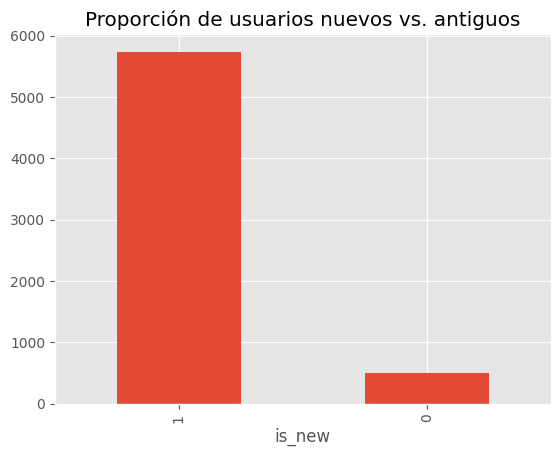

In [100]:
df_churn["is_new"] = (
    df_churn["max_start_contrato_nuevo_date"].isna() |
    (df_churn["max_start_contrato_nuevo_date"] == df_churn["min_start_contrato_date"]) # Si fuera NaT, siempre daría False
).astype(int)

df_churn.groupby("advertiser_zrive_id")["is_new"].max().value_counts().plot(kind='bar')
plt.title("Proporción de usuarios nuevos vs. antiguos")

Casi todos los usuarios son nuevos

#### Nueva feature **n_withdrawal_attempts**

**n_withdrawal_attempts**: se define como el número de intentos de withdrawals, obtenido con los valores únicos de **withdrawal_id** de cada advertiser. Si un advertiser tiene 6 withdrawal_id distintos, se cuentan únicamente aquellos donde el withdrawal no llegó a ser definitivo (is_definitive_withdrawal = 0)


In [101]:
df_churn.head()

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,...,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal,start_date,snapshot_date,end_date,permanencia,dias_permanencia,is_active,is_new
0,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,4758.0,Cerrada,...,2015-03-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114,1,1
1,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,23029.0,Cerrada,...,2018-11-01,RESULTADOS,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114,1,1
2,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,32827.0,Cerrada,...,2020-11-20,Cambio a Bundle Online,0.0,2025-01-07,2025-05-01,2025-05-01,114 days,114,1,1
3,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,33518.0,Cerrada,...,2021-02-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114,1,1
4,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,54519.0,Cerrada,...,2025-05-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114,1,1


In [102]:
df_churn = df_churn.copy()     
df_churn["n_withdrawal_attempts"] = (
    df_churn["withdrawal_id"]
      .where(df_churn["is_definitive_withdrawal"].eq(0))
      .groupby(df_churn["advertiser_zrive_id"])
      .transform("nunique")
      .fillna(0)
      .astype(int)
)

In [103]:
df_churn[df_churn["snapshot_date"]>=df_churn["end_date"]]

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,...,withdrawal_reason,is_definitive_withdrawal,start_date,snapshot_date,end_date,permanencia,dias_permanencia,is_active,is_new,n_withdrawal_attempts
0,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,4758.0,Cerrada,...,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114,1,1,1
1,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,23029.0,Cerrada,...,RESULTADOS,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114,1,1,1
2,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,32827.0,Cerrada,...,Cambio a Bundle Online,0.0,2025-01-07,2025-05-01,2025-05-01,114 days,114,1,1,1
3,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,33518.0,Cerrada,...,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114,1,1,1
4,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,54519.0,Cerrada,...,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01,2025-05-01,114 days,114,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23718,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,46264.0,Cerrada,...,Cambio de Contrato/propuesta/producto,0.0,2022-07-21,2023-10-10,2023-10-10,446 days,446,1,1,1
23719,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,47376.0,Cerrada,...,FALTA DE USO/TIEMPO,1.0,2022-07-21,2023-10-10,2023-10-10,446 days,446,1,1,1
23720,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,48614.0,Cerrada,...,RAZONES ECONOMICAS,1.0,2022-07-21,2023-10-10,2023-10-10,446 days,446,1,1,1
23721,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,51090.0,Cerrada,...,RESULTADOS,1.0,2022-07-21,2023-10-10,2023-10-10,446 days,446,1,1,1


In [104]:
df_churn[df_churn["n_withdrawal_attempts"]>1]

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,...,withdrawal_reason,is_definitive_withdrawal,start_date,snapshot_date,end_date,permanencia,dias_permanencia,is_active,is_new,n_withdrawal_attempts
44,534,8,2024-07-05 11:33:04,Barcelona,41.0,2024-04-30,NaT,2024-06-29,4892.0,Cerrada,...,RESULTADOS,1.0,2024-04-30,2024-07-05,2024-06-29,60 days,60,0,1,5
45,534,8,2024-07-05 11:33:04,Barcelona,41.0,2024-04-30,NaT,2024-06-29,14657.0,Cerrada,...,FALTA DE PRODUCTO,1.0,2024-04-30,2024-07-05,2024-06-29,60 days,60,0,1,5
46,534,8,2024-07-05 11:33:04,Barcelona,41.0,2024-04-30,NaT,2024-06-29,28025.0,Cerrada,...,Cambio a Bundle Online,0.0,2024-04-30,2024-07-05,2024-06-29,60 days,60,0,1,5
47,534,8,2024-07-05 11:33:04,Barcelona,41.0,2024-04-30,NaT,2024-06-29,28175.0,Cerrada,...,Cambio a Bundle Online,0.0,2024-04-30,2024-07-05,2024-06-29,60 days,60,0,1,5
48,534,8,2024-07-05 11:33:04,Barcelona,41.0,2024-04-30,NaT,2024-06-29,28220.0,Cerrada,...,Upselling-cambio de contrato,0.0,2024-04-30,2024-07-05,2024-06-29,60 days,60,0,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23687,3166,46,2025-02-27 14:21:20,Valencia,NaN,2021-05-14,2024-11-27,2025-06-30,45070.0,Cerrada,...,MOROSIDAD,1.0,2024-11-27,2025-02-27,2025-02-27,92 days,92,1,0,2
23688,3166,46,2025-02-27 14:21:20,Valencia,NaN,2021-05-14,2024-11-27,2025-06-30,46400.0,Cerrada,...,Upselling-cambio de contrato,0.0,2024-11-27,2025-02-27,2025-02-27,92 days,92,1,0,2
23689,3166,46,2025-02-27 14:21:20,Valencia,NaN,2021-05-14,2024-11-27,2025-06-30,48906.0,Cerrada,...,RESULTADOS,1.0,2024-11-27,2025-02-27,2025-02-27,92 days,92,1,0,2
23690,3166,46,2025-02-27 14:21:20,Valencia,NaN,2021-05-14,2024-11-27,2025-06-30,50079.0,Cerrada,...,RESULTADOS,1.0,2024-11-27,2025-02-27,2025-02-27,92 days,92,1,0,2


### Ejemplo:
- Vemos el comportamiento de un usuario y el nº de intentos de withdrawal (nótese que los intentos que fueron definitivos (is_definitive_withdrawal=1) lógicamente no se cuentan). 
- Advertiser **534**:
¿Cuántos is_definitive_withdrawal == 0 únicos tiene? --> 5

In [105]:
df_churn[df_churn["advertiser_zrive_id"]==534]

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,...,withdrawal_reason,is_definitive_withdrawal,start_date,snapshot_date,end_date,permanencia,dias_permanencia,is_active,is_new,n_withdrawal_attempts
44,534,8,2024-07-05 11:33:04,Barcelona,41.0,2024-04-30,NaT,2024-06-29,4892.0,Cerrada,...,RESULTADOS,1.0,2024-04-30,2024-07-05,2024-06-29,60 days,60,0,1,5
45,534,8,2024-07-05 11:33:04,Barcelona,41.0,2024-04-30,NaT,2024-06-29,14657.0,Cerrada,...,FALTA DE PRODUCTO,1.0,2024-04-30,2024-07-05,2024-06-29,60 days,60,0,1,5
46,534,8,2024-07-05 11:33:04,Barcelona,41.0,2024-04-30,NaT,2024-06-29,28025.0,Cerrada,...,Cambio a Bundle Online,0.0,2024-04-30,2024-07-05,2024-06-29,60 days,60,0,1,5
47,534,8,2024-07-05 11:33:04,Barcelona,41.0,2024-04-30,NaT,2024-06-29,28175.0,Cerrada,...,Cambio a Bundle Online,0.0,2024-04-30,2024-07-05,2024-06-29,60 days,60,0,1,5
48,534,8,2024-07-05 11:33:04,Barcelona,41.0,2024-04-30,NaT,2024-06-29,28220.0,Cerrada,...,Upselling-cambio de contrato,0.0,2024-04-30,2024-07-05,2024-06-29,60 days,60,0,1,5
49,534,8,2024-07-05 11:33:04,Barcelona,41.0,2024-04-30,NaT,2024-06-29,28966.0,Cerrada,...,CORONAVIRUS,1.0,2024-04-30,2024-07-05,2024-06-29,60 days,60,0,1,5
50,534,8,2024-07-05 11:33:04,Barcelona,41.0,2024-04-30,NaT,2024-06-29,31242.0,Cerrada,...,MOROSIDAD,0.0,2024-04-30,2024-07-05,2024-06-29,60 days,60,0,1,5
51,534,8,2024-07-05 11:33:04,Barcelona,41.0,2024-04-30,NaT,2024-06-29,32327.0,Cerrada,...,MOROSIDAD,1.0,2024-04-30,2024-07-05,2024-06-29,60 days,60,0,1,5
52,534,8,2024-07-05 11:33:04,Barcelona,41.0,2024-04-30,NaT,2024-06-29,33360.0,Cerrada,...,MOROSIDAD,1.0,2024-04-30,2024-07-05,2024-06-29,60 days,60,0,1,5
53,534,8,2024-07-05 11:33:04,Barcelona,41.0,2024-04-30,NaT,2024-06-29,38879.0,Cerrada,...,MOROSIDAD,1.0,2024-04-30,2024-07-05,2024-06-29,60 days,60,0,1,5


### Agregación final

Ahora, como tenemos varios registros e información de withdrawal a nivel advertiser_id, aplicamos una lógica para quedarnos con 1 fila = 1 advertiser

In [106]:
df_churn[df_churn["advertiser_zrive_id"] == 417]

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,...,withdrawal_reason,is_definitive_withdrawal,start_date,snapshot_date,end_date,permanencia,dias_permanencia,is_active,is_new,n_withdrawal_attempts
2917,417,9,2025-06-11 09:38:30,Burgos,NaN,2020-03-17,2020-03-17,NaT,10570.0,Cerrada,...,RATIO RESULTADO-INVERSION,0.0,2020-03-17,2025-06-11,2025-06-11,1912 days,1912,1,1,7
2918,417,9,2025-06-11 09:38:30,Burgos,NaN,2020-03-17,2020-03-17,NaT,19933.0,Cerrada,...,RATIO RESULTADO-INVERSION,0.0,2020-03-17,2025-06-11,2025-06-11,1912 days,1912,1,1,7
2919,417,9,2025-06-11 09:38:30,Burgos,NaN,2020-03-17,2020-03-17,NaT,24455.0,Cerrada,...,OTROS,0.0,2020-03-17,2025-06-11,2025-06-11,1912 days,1912,1,1,7
2920,417,9,2025-06-11 09:38:30,Burgos,NaN,2020-03-17,2020-03-17,NaT,28731.0,Cerrada,...,Cambio a Bundle Online,0.0,2020-03-17,2025-06-11,2025-06-11,1912 days,1912,1,1,7
2921,417,9,2025-06-11 09:38:30,Burgos,NaN,2020-03-17,2020-03-17,NaT,44849.0,Cerrada,...,RESULTADOS,1.0,2020-03-17,2025-06-11,2023-07-01,1201 days,1201,0,1,7
2922,417,9,2025-06-11 09:38:30,Burgos,NaN,2020-03-17,2020-03-17,NaT,44852.0,Cerrada,...,Cambio de Contrato/propuesta/producto,0.0,2020-03-17,2025-06-11,2025-06-11,1912 days,1912,1,1,7
2923,417,9,2025-06-11 09:38:30,Burgos,NaN,2020-03-17,2020-03-17,NaT,46601.0,Cerrada,...,RESULTADOS,1.0,2020-03-17,2025-06-11,2023-11-01,1324 days,1324,0,1,7
2924,417,9,2025-06-11 09:38:30,Burgos,NaN,2020-03-17,2020-03-17,NaT,46633.0,Cerrada,...,RESULTADOS,0.0,2020-03-17,2025-06-11,2025-06-11,1912 days,1912,1,1,7
2925,417,9,2025-06-11 09:38:30,Burgos,NaN,2020-03-17,2020-03-17,NaT,47574.0,Cerrada,...,RAZONES ECONOMICAS,1.0,2020-03-17,2025-06-11,2024-02-01,1416 days,1416,0,1,7
2926,417,9,2025-06-11 09:38:30,Burgos,NaN,2020-03-17,2020-03-17,NaT,47964.0,Cerrada,...,RESULTADOS,1.0,2020-03-17,2025-06-11,2025-06-11,1912 days,1912,1,1,7


Detectamos un "bug": por ejemplo, el usuario **417** que inició un contrato el 2020-03-17 pero se dió de baja definitiva en 3 fechas distintas... ¿con qué fecha de salida nos quedamos?
-> Decidimos que con la mínima: el churn es el PRIMER withdrawal definitivo efectivo del contrato actual. Para ello, creamos el dataframe **df_churn_first**, es decir, nos quedamos con la primera fecha de withdrawal

In [107]:
df_churn_first = df_churn.loc[
    df_churn.groupby("advertiser_zrive_id")["end_date"].idxmin()
]

df_churn_first[df_churn_first["advertiser_zrive_id"] == 417]

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,...,withdrawal_reason,is_definitive_withdrawal,start_date,snapshot_date,end_date,permanencia,dias_permanencia,is_active,is_new,n_withdrawal_attempts
2921,417,9,2025-06-11 09:38:30,Burgos,NaN,2020-03-17,2020-03-17,NaT,44849.0,Cerrada,...,RESULTADOS,1.0,2020-03-17,2025-06-11,2023-07-01,1201 days,1201,0,1,7


In [108]:
df_churn_first.head()

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,...,withdrawal_reason,is_definitive_withdrawal,start_date,snapshot_date,end_date,permanencia,dias_permanencia,is_active,is_new,n_withdrawal_attempts
13704,1,11,2023-06-16 09:35:01,Cádiz,NaN,2020-12-23,NaT,2023-05-31,6733.0,Cerrada,...,FALTA DE USO/TIEMPO,1.0,2020-12-23,2023-06-16,2023-05-31,889 days,889,0,1,5
3217,2,11,2023-11-06 16:01:14,Cádiz,100.0,2020-09-25,2020-09-25,NaT,4770.0,Cerrada,...,RESULTADOS,1.0,2020-09-25,2023-11-06,2023-11-06,1137 days,1137,1,1,1
79,3,8,2024-08-07 13:37:09,Barcelona,41.0,2024-05-06,NaT,2024-07-15,41236.0,Cerrada,...,RESULTADOS,1.0,2024-05-06,2024-08-07,2024-07-15,70 days,70,0,1,0
11568,4,48,2023-05-03 16:37:02,Vizcaya,NaN,2022-09-30,NaT,NaT,148.0,Cerrada,...,OTROS,1.0,2022-09-30,2023-05-03,2023-05-03,215 days,215,1,1,7
11520,5,48,2025-01-07 17:47:31,Vizcaya,193.0,2024-07-30,2024-09-30,NaT,3614.0,Cerrada,...,FALTA DE PRODUCTO,0.0,2024-09-30,2025-01-07,2025-01-07,99 days,99,1,0,10


Creamos una nueva variable para identificar advertisers individuales de aquellos que pertenecen a un grupo

In [109]:
largest_group = df_churn_first.groupby("advertiser_group_id")["advertiser_zrive_id"].nunique().idxmax()
n_adv_largest_group = df_churn_first[df_churn_first["advertiser_group_id"] == largest_group]["advertiser_zrive_id"].nunique()

print(f"El grupo/empresa más grande en volúmen de advertisers es el: {largest_group}, con {n_adv_largest_group} advertisers distintos")


El grupo/empresa más grande en volúmen de advertisers es el: 125.0, con 244 advertisers distintos


In [110]:
df_churn_first[df_churn_first["is_definitive_withdrawal"] == 1]

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,...,withdrawal_reason,is_definitive_withdrawal,start_date,snapshot_date,end_date,permanencia,dias_permanencia,is_active,is_new,n_withdrawal_attempts
13704,1,11,2023-06-16 09:35:01,Cádiz,NaN,2020-12-23,NaT,2023-05-31,6733.0,Cerrada,...,FALTA DE USO/TIEMPO,1.0,2020-12-23,2023-06-16,2023-05-31,889 days,889,0,1,5
3217,2,11,2023-11-06 16:01:14,Cádiz,100.0,2020-09-25,2020-09-25,NaT,4770.0,Cerrada,...,RESULTADOS,1.0,2020-09-25,2023-11-06,2023-11-06,1137 days,1137,1,1,1
79,3,8,2024-08-07 13:37:09,Barcelona,41.0,2024-05-06,NaT,2024-07-15,41236.0,Cerrada,...,RESULTADOS,1.0,2024-05-06,2024-08-07,2024-07-15,70 days,70,0,1,0
11568,4,48,2023-05-03 16:37:02,Vizcaya,NaN,2022-09-30,NaT,NaT,148.0,Cerrada,...,OTROS,1.0,2022-09-30,2023-05-03,2023-05-03,215 days,215,1,1,7
11717,6,48,2025-03-12 13:48:02,Vizcaya,NaN,2022-10-10,NaT,NaT,446.0,Cerrada,...,RESULTADOS,1.0,2022-10-10,2025-03-12,2025-03-12,884 days,884,1,1,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6855,6897,29,2025-06-04 13:31:07,Madrid,NaN,2025-03-04,2025-03-04,NaT,55470.0,Cerrada,...,MOROSIDAD,1.0,2025-03-04,2025-06-04,2025-06-04,92 days,92,1,1,0
4766,6900,24,2025-06-06 13:37:22,Islas Baleares,NaN,2025-03-05,2025-03-05,NaT,55591.0,Cerrada,...,MOROSIDAD,1.0,2025-03-05,2025-06-06,2025-06-06,93 days,93,1,1,0
4339,6901,19,2025-06-05 19:00:08,Granada,NaN,2025-03-05,2025-03-05,NaT,55194.0,Cerrada,...,RESULTADOS,1.0,2025-03-05,2025-06-05,2025-06-05,92 days,92,1,1,0
23050,6931,3,2025-06-01 03:58:05,Alicante,NaN,2025-03-28,2025-03-28,2025-05-31,55483.0,Cerrada,...,MOROSIDAD,1.0,2025-03-28,2025-06-01,2025-05-31,64 days,64,0,1,0


In [111]:
df_churn_first.head()

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,...,withdrawal_reason,is_definitive_withdrawal,start_date,snapshot_date,end_date,permanencia,dias_permanencia,is_active,is_new,n_withdrawal_attempts
13704,1,11,2023-06-16 09:35:01,Cádiz,NaN,2020-12-23,NaT,2023-05-31,6733.0,Cerrada,...,FALTA DE USO/TIEMPO,1.0,2020-12-23,2023-06-16,2023-05-31,889 days,889,0,1,5
3217,2,11,2023-11-06 16:01:14,Cádiz,100.0,2020-09-25,2020-09-25,NaT,4770.0,Cerrada,...,RESULTADOS,1.0,2020-09-25,2023-11-06,2023-11-06,1137 days,1137,1,1,1
79,3,8,2024-08-07 13:37:09,Barcelona,41.0,2024-05-06,NaT,2024-07-15,41236.0,Cerrada,...,RESULTADOS,1.0,2024-05-06,2024-08-07,2024-07-15,70 days,70,0,1,0
11568,4,48,2023-05-03 16:37:02,Vizcaya,NaN,2022-09-30,NaT,NaT,148.0,Cerrada,...,OTROS,1.0,2022-09-30,2023-05-03,2023-05-03,215 days,215,1,1,7
11520,5,48,2025-01-07 17:47:31,Vizcaya,193.0,2024-07-30,2024-09-30,NaT,3614.0,Cerrada,...,FALTA DE PRODUCTO,0.0,2024-09-30,2025-01-07,2025-01-07,99 days,99,1,0,10


In [112]:
df_churn_first = df_churn_first.copy()
df_churn_first["is_individual"] = (
    df_churn_first["advertiser_group_id"].isna()
).astype(int)

# df_churn_first["dias_permanencia"] = df_churn_first["dias_permanencia"].dt.days
df = df_churn_first.copy()

### **Early churn**

Ahora definimos el evento de early churn, es decir si los dias de permanencia en la plataforma fueron menos de 90 días o más

- usuarios con churn_3m=1
- usuarios con churn_3m=0
- usuarios censurados (NA): estos son aquellos cuya end_date = snapshot_date, es decir, no podemos certificar que end_date es la fecha de baja ya que realmente es la última fecha de actualización de información de ese advertiser, con lo cual en esa fecha el usuario aun seguía activo y no sabemos si en el futuro hizo churn o no

OJO: en los casos en los que end_date >= snapshot_date, no podemos afirmar si es churn o no

Desde **start_date**, ¿ocurre algún evento de churn en los siguientes 90 días?

In [113]:
df[df["dias_permanencia"] < 90]

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,...,is_definitive_withdrawal,start_date,snapshot_date,end_date,permanencia,dias_permanencia,is_active,is_new,n_withdrawal_attempts,is_individual
79,3,8,2024-08-07 13:37:09,Barcelona,41.0,2024-05-06,NaT,2024-07-15,41236.0,Cerrada,...,1.0,2024-05-06,2024-08-07,2024-07-15,70 days,70,0,1,0,0
231,17,46,2023-03-29 11:00:19,Valencia,NaN,2023-01-10,NaT,2023-03-12,41579.0,Cerrada,...,1.0,2023-01-10,2023-03-29,2023-03-12,61 days,61,0,1,0,1
239,19,46,2023-07-16 01:00:47,Valencia,NaN,2023-05-16,NaT,2023-07-15,6372.0,Cerrada,...,1.0,2023-05-16,2023-07-16,2023-07-15,60 days,60,0,1,0,1
12287,46,29,2023-02-09 10:03:17,Madrid,NaN,2021-04-23,NaT,2023-01-31,35197.0,Cerrada,...,1.0,2021-04-23,2023-02-09,2021-05-20,27 days,27,0,1,0,1
13660,76,8,2023-09-21 17:00:56,Barcelona,115.0,2023-04-19,NaT,2023-05-31,4988.0,Cerrada,...,0.0,2023-04-19,2023-09-21,2023-05-31,42 days,42,0,1,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23378,6864,30,2025-06-01 03:54:11,Málaga,NaN,2025-03-07,2025-03-07,2025-05-31,55301.0,Cerrada,...,1.0,2025-03-07,2025-06-01,2025-05-31,85 days,85,0,1,0,1
22914,6868,31,2025-05-14 10:00:10,Murcia,NaN,2025-02-20,2025-02-20,2025-04-30,55126.0,Cerrada,...,1.0,2025-02-20,2025-05-14,2025-04-30,69 days,69,0,1,0,1
22902,6878,30,2025-05-01 05:16:06,Málaga,NaN,2025-02-26,2025-02-26,2025-04-30,54702.0,Cerrada,...,1.0,2025-02-26,2025-05-01,2025-04-30,63 days,63,0,1,0,1
23050,6931,3,2025-06-01 03:58:05,Alicante,NaN,2025-03-28,2025-03-28,2025-05-31,55483.0,Cerrada,...,1.0,2025-03-28,2025-06-01,2025-05-31,64 days,64,0,1,0,1


In [114]:
df["is_early_churn"] = (
    df["dias_permanencia"] < 90
).astype(int)

In [115]:
df[df["withdrawal_creation_date"]<df["start_date"]]

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,...,start_date,snapshot_date,end_date,permanencia,dias_permanencia,is_active,is_new,n_withdrawal_attempts,is_individual,is_early_churn
13704,1,11,2023-06-16 09:35:01,Cádiz,NaN,2020-12-23,NaT,2023-05-31,6733.0,Cerrada,...,2020-12-23,2023-06-16,2023-05-31,889 days,889,0,1,5,1,0
3217,2,11,2023-11-06 16:01:14,Cádiz,100.0,2020-09-25,2020-09-25,NaT,4770.0,Cerrada,...,2020-09-25,2023-11-06,2023-11-06,1137 days,1137,1,1,1,0,0
79,3,8,2024-08-07 13:37:09,Barcelona,41.0,2024-05-06,NaT,2024-07-15,41236.0,Cerrada,...,2024-05-06,2024-08-07,2024-07-15,70 days,70,0,1,0,0,1
11568,4,48,2023-05-03 16:37:02,Vizcaya,NaN,2022-09-30,NaT,NaT,148.0,Cerrada,...,2022-09-30,2023-05-03,2023-05-03,215 days,215,1,1,7,1,0
11520,5,48,2025-01-07 17:47:31,Vizcaya,193.0,2024-07-30,2024-09-30,NaT,3614.0,Cerrada,...,2024-09-30,2025-01-07,2025-01-07,99 days,99,1,0,10,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19584,5845,29,2024-11-07 12:43:00,Madrid,193.0,2024-02-21,2024-06-03,2024-10-31,49191.0,Cerrada,...,2024-06-03,2024-11-07,2024-10-31,150 days,150,0,0,1,0,0
21272,5917,31,2025-02-01 03:58:04,Murcia,NaN,2024-03-11,2024-11-22,2025-01-31,49430.0,Cerrada,...,2024-11-22,2025-02-01,2025-01-31,70 days,70,0,0,1,1,1
4061,6013,17,2025-06-06 19:02:06,Cuenca,NaN,2024-05-22,2025-03-06,NaT,50444.0,Cerrada,...,2025-03-06,2025-06-06,2025-06-06,92 days,92,1,0,0,1,0
10324,6244,43,2025-05-11 11:37:06,Tenerife,NaN,2024-06-18,2025-02-10,NaT,51222.0,Cerrada,...,2025-02-10,2025-05-11,2025-05-11,90 days,90,1,0,0,1,0


<Axes: xlabel='is_early_churn'>

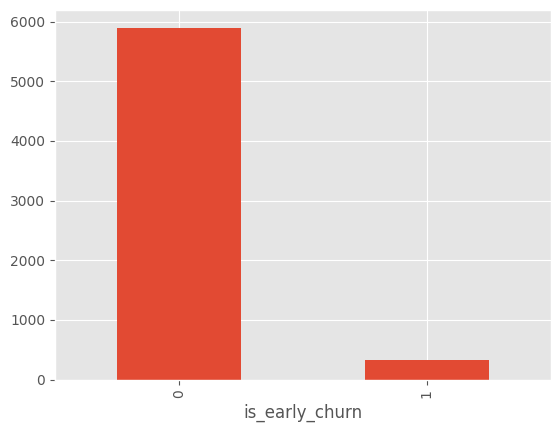

In [116]:
df["is_early_churn"].value_counts().plot(kind='bar')

Dataset muy desbalanceado

<Axes: ylabel='Frequency'>

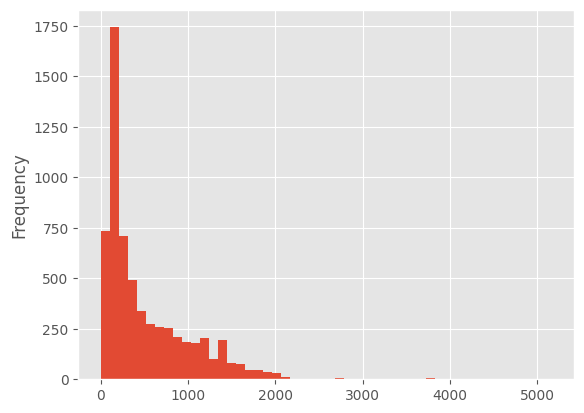

In [117]:
df["dias_permanencia"].plot(kind='hist', bins=50)

In [118]:
(df["dias_permanencia"] < 90).mean()


np.float64(0.053568564554931836)

In [119]:
df["dias_permanencia"].describe()


count    6235.000000
mean      521.690136
std       520.273778
min         0.000000
25%       151.000000
50%       299.000000
75%       771.000000
max      5169.000000
Name: dias_permanencia, dtype: float64

<Axes: ylabel='dias_permanencia'>

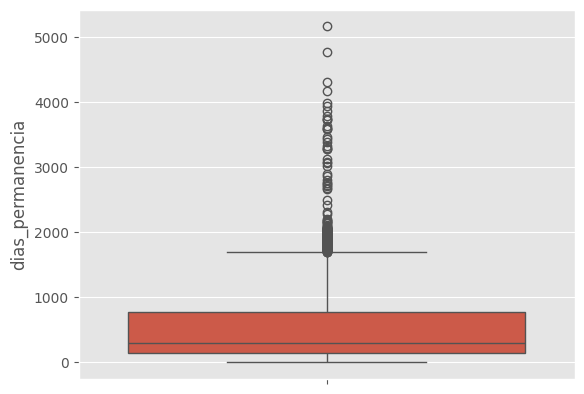

In [120]:
sns.boxplot(df["dias_permanencia"])

In [121]:
df["dias_permanencia"].value_counts().sort_values().reset_index()

,dias_permanencia,count
0,611,1
1,473,1
2,468,1
3,581,1
4,568,1
...,...,...
1499,93,50
1500,152,62
1501,151,70
1502,92,81


In [167]:
df.shape

(6235, 25)

In [181]:
df[df["advertiser_zrive_id"]==1]

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,...,start_date,snapshot_date,end_date,permanencia,dias_permanencia,is_active,is_new,n_withdrawal_attempts,is_individual,is_early_churn
13704,1,11,2023-06-16 09:35:01,Cádiz,NaN,2020-12-23,NaT,2023-05-31,6733.0,Cerrada,...,2020-12-23,2023-06-16,2023-05-31,889 days,889,0,1,5,1,0


In [182]:
df_period_check = df.copy()

In [183]:
df_fct_max_period = (
    df_fct
    .groupby("advertiser_zrive_id")["period_int"]
    .max()
    .reset_index()
    .rename(columns={'period_int':'max_period_int'})
)
df_fct_max_period

,advertiser_zrive_id,max_period_int
0,1,2023-05-01
1,2,2025-05-01
2,3,2024-07-01
3,4,2025-05-01
4,5,2025-05-01
...,...,...
6963,7047,2025-05-01
6964,7051,2025-05-01
6965,7052,2025-05-01
6966,7066,2025-05-01


In [184]:
df_period_check = df_period_check.merge(df_fct_max_period, how='inner', on='advertiser_zrive_id')
df_period_check

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,...,snapshot_date,end_date,permanencia,dias_permanencia,is_active,is_new,n_withdrawal_attempts,is_individual,is_early_churn,max_period_int
0,1,11,2023-06-16 09:35:01,Cádiz,NaN,2020-12-23,NaT,2023-05-31,6733.0,Cerrada,...,2023-06-16,2023-05-31,889 days,889,0,1,5,1,0,2023-05-01
1,2,11,2023-11-06 16:01:14,Cádiz,100.0,2020-09-25,2020-09-25,NaT,4770.0,Cerrada,...,2023-11-06,2023-11-06,1137 days,1137,1,1,1,0,0,2025-05-01
2,3,8,2024-08-07 13:37:09,Barcelona,41.0,2024-05-06,NaT,2024-07-15,41236.0,Cerrada,...,2024-08-07,2024-07-15,70 days,70,0,1,0,0,1,2024-07-01
3,4,48,2023-05-03 16:37:02,Vizcaya,NaN,2022-09-30,NaT,NaT,148.0,Cerrada,...,2023-05-03,2023-05-03,215 days,215,1,1,7,1,0,2025-05-01
4,5,48,2025-01-07 17:47:31,Vizcaya,193.0,2024-07-30,2024-09-30,NaT,3614.0,Cerrada,...,2025-01-07,2025-01-07,99 days,99,1,0,10,0,0,2025-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6201,6909,5,2025-06-11 13:25:09,Asturias,NaN,2025-03-10,NaT,NaT,NaN,NaN,...,2025-06-11,2025-06-11,93 days,93,1,1,0,1,0,2025-05-01
6202,6913,31,2025-06-12 13:27:01,Murcia,NaN,2025-03-12,2025-03-12,NaT,NaN,NaN,...,2025-06-12,2025-06-12,92 days,92,1,1,0,1,0,2025-05-01
6203,6923,40,2025-06-18 12:12:19,Sevilla,55.0,2025-03-17,2025-03-17,NaT,NaN,NaN,...,2025-06-18,2025-06-18,93 days,93,1,1,0,0,0,2025-05-01
6204,6931,3,2025-06-01 03:58:05,Alicante,NaN,2025-03-28,2025-03-28,2025-05-31,55483.0,Cerrada,...,2025-06-01,2025-05-31,64 days,64,0,1,0,1,1,2025-05-01


## FCT analysis

In [122]:
df["advertiser_zrive_id"].nunique()

6235

In [196]:
df_fct = df_fct.drop_duplicates()

In [197]:
df_fct["advertiser_zrive_id"].nunique()

6968

In [199]:
df_fct["monthly_total_invoice"].describe()

count    96827.000000
mean       502.412151
std       1048.308252
min          0.000000
25%         71.600000
50%        235.000000
75%        545.000000
max      33500.000000
Name: monthly_total_invoice, dtype: float64

<Axes: >

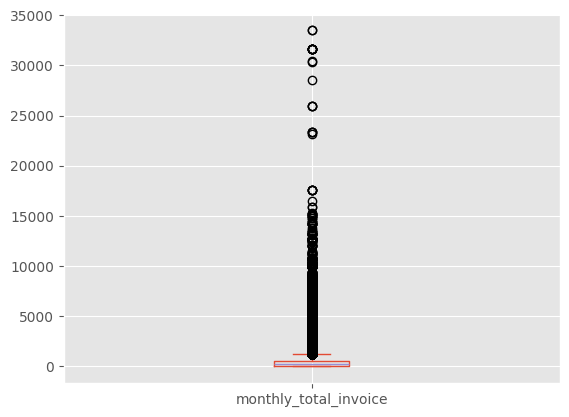

In [200]:
df_fct["monthly_total_invoice"].plot(kind='box')

In [201]:
df_fct = df_fct[df_fct["monthly_total_invoice"] >= 0]
df_fct["monthly_total_invoice"].describe()

count    96827.000000
mean       502.412151
std       1048.308252
min          0.000000
25%         71.600000
50%        235.000000
75%        545.000000
max      33500.000000
Name: monthly_total_invoice, dtype: float64

In [202]:
from scipy.stats import variation

variation(df_fct["monthly_total_invoice"])

np.float64(2.086539581807757)

Text(0.5, 1.0, 'Distribución del precio real')

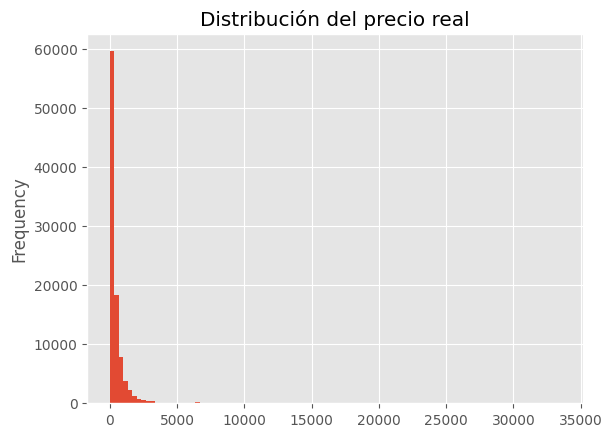

In [203]:
df_fct["monthly_total_invoice"].plot(kind="hist", bins=100)
plt.title("Distribución del precio real")

In [204]:
df_fct.describe()

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_leads,monthly_total_phone_views,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price
count,96827.000000,96827,96827.000000,96827.000000,96827.00000,86775.000000,96827.000000,96827.000000,96827.000000,96827.000000,...,96827.000000,96827.000000,96827.000000,96827.000000,96827.000000,84498.000000,96827.000000,96827.000000,96827.000000,8.836000e+04
mean,2994.207866,2024-03-01 02:55:41.786898176,108.101191,93.381774,50.39962,181.334947,3.057453,1.577008,1.654972,0.389984,...,19.562261,12.317257,8.584279,4.729673,502.412151,1325.395421,6.134973,9.332624,15.467597,2.869974e+04
min,1.000000,2023-01-01 00:00:00,0.000000,0.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.300000,0.000000,0.000000,0.000000,1.000000e+00
25%,1364.000000,2023-08-01 00:00:00,6.000000,3.000000,3.00000,6.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,1.000000,0.000000,0.000000,71.600000,361.700000,0.000000,1.000000,1.000000,1.433743e+04
50%,2782.000000,2024-03-01 00:00:00,20.000000,12.000000,10.00000,18.000000,0.000000,0.000000,0.000000,0.000000,...,6.000000,4.000000,3.000000,1.000000,235.000000,548.300000,2.000000,3.000000,5.000000,2.042249e+04
75%,4514.000000,2024-10-01 00:00:00,50.000000,38.000000,34.00000,60.000000,2.000000,2.000000,2.000000,0.000000,...,18.000000,13.000000,8.000000,5.000000,545.000000,1105.000000,6.000000,9.000000,15.000000,2.799000e+04
max,7069.000000,2025-05-01 00:00:00,8200.000000,8200.000000,5400.00000,133865.000000,900.000000,165.000000,120.000000,900.000000,...,1983.000000,926.000000,1098.000000,406.000000,33500.000000,696546.700000,799.000000,716.000000,1515.000000,3.705341e+07
std,1902.383463,NaN,490.209838,478.776149,243.68727,1250.878986,19.359616,4.308079,4.098040,8.207100,...,52.583756,28.280672,24.388530,12.075520,1048.308252,5554.633364,16.616800,23.543399,39.382878,1.460678e+05


In [205]:
try:
    df_fct["period_int"] = pd.to_datetime(df_fct['period_int'].astype(str), format="%Y%m")
except ValueError:
    pass

df_fct

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_phone_views,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract
0,1,2023-01-01,75,47,47,56.0,6,6,6,0,...,14,15,0,1714.2,2416.7,12,3,15,42667.86,True
1,2,2023-01-01,150,31,31,55.0,10,10,4,0,...,16,2,2,293.3,3643.3,2,2,4,22742.40,True
2,3,2023-01-01,0,0,0,NaN,0,0,0,0,...,0,0,0,0.0,NaN,0,0,0,25420.83,False
3,4,2023-01-01,85,79,79,86.0,3,3,1,0,...,10,8,2,1165.0,3023.3,6,6,12,23259.52,True
4,6,2023-01-01,20,20,20,25.0,0,0,1,0,...,10,4,3,336.3,515.0,4,11,15,43439.00,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96824,7047,2025-05-01,3,0,0,NaN,0,0,2,0,...,0,0,0,0.0,NaN,0,0,0,NaN,True
96825,7051,2025-05-01,20,0,0,NaN,0,0,0,0,...,0,0,0,0.0,NaN,0,0,0,NaN,True
96826,7052,2025-05-01,3,0,0,NaN,0,0,2,0,...,0,0,0,0.0,NaN,0,0,0,NaN,True
96827,7066,2025-05-01,20,20,20,29.0,3,3,7,0,...,6,24,4,0.0,NaN,17,26,43,9859.33,False


In [206]:
df_fct["period_int"].describe()

count                            96827
mean     2024-03-01 02:55:41.786898176
min                2023-01-01 00:00:00
25%                2023-08-01 00:00:00
50%                2024-03-01 00:00:00
75%                2024-10-01 00:00:00
max                2025-05-01 00:00:00
Name: period_int, dtype: object

<Axes: ylabel='Frequency'>

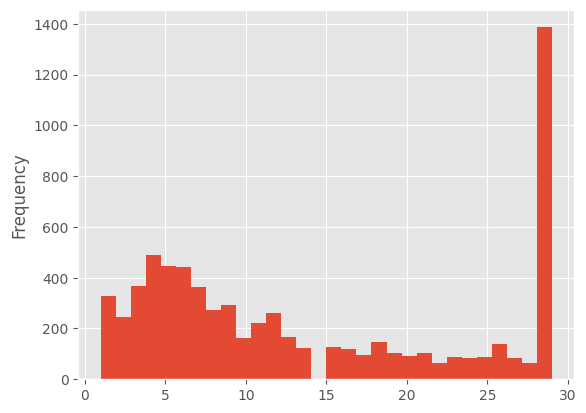

In [207]:
(
    df_fct
    .groupby("advertiser_zrive_id")["period_int"]
    .nunique()
).plot(kind='hist', bins=30)

Distribución bimodal: hay un segmento de clientes de corto plazo (al rededor de 5 meses de estancia) y otro de clientes de largo plazo (29 meses de estancia)

<Axes: xlabel='monthly_total_invoice', ylabel='n_months'>

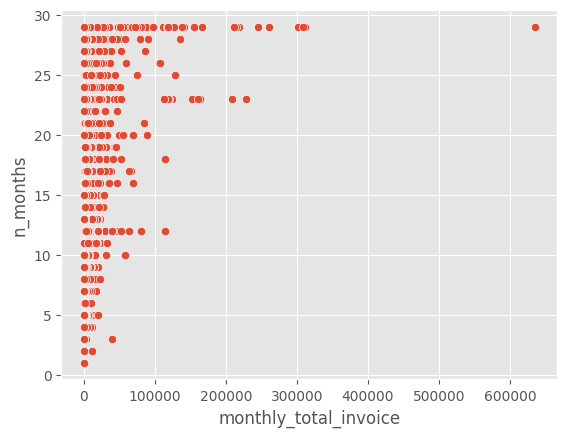

In [208]:
months = df_fct.groupby("advertiser_zrive_id")["period_int"].nunique()

df_clients = df_fct.groupby("advertiser_zrive_id").agg({
    "monthly_total_invoice": "sum",
    "monthly_contracted_ads": "median"
}).join(months.rename("n_months"))

import seaborn as sns
sns.scatterplot(data=df_clients, x="monthly_total_invoice", y="n_months")


In [209]:
from sklearn.cluster import KMeans

X = df_clients[["n_months"]]
kmeans = KMeans(n_clusters=2, random_state=0).fit(X)
df_clients["cluster"] = kmeans.labels_


In [210]:
df_clients

,monthly_total_invoice,monthly_contracted_ads,n_months,cluster
advertiser_zrive_id,,,,
1,8944.2,50.0,5,1
2,5519.9,150.0,29,0
3,0.0,35.0,4,1
4,51437.6,100.0,29,0
5,7618.2,100.0,11,1
...,...,...,...,...
7047,0.0,3.0,1,1
7051,0.0,20.0,1,1
7052,0.0,3.0,1,1


Text(0.5, 1.0, 'Clientes a corto vs largo plazo')

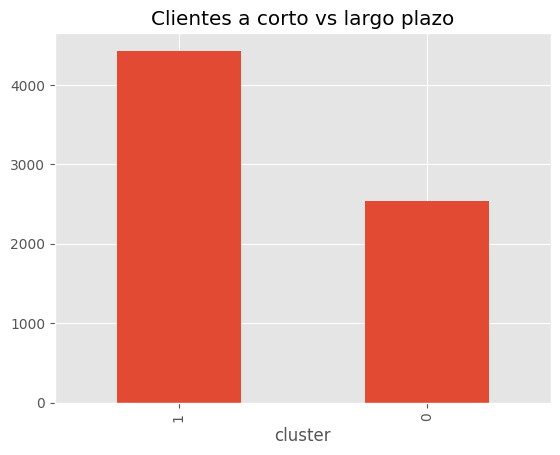

In [211]:
df_clients["cluster"].value_counts().plot(kind='bar')
plt.title("Clientes a corto vs largo plazo")

In [212]:
df_clients[df_clients["cluster"]==1]['n_months'].describe()

count    4429.000000
mean        7.011967
std         4.071192
min         1.000000
25%         4.000000
50%         6.000000
75%        10.000000
max        16.000000
Name: n_months, dtype: float64

In [213]:
df_clients[df_clients["cluster"]==0]['n_months'].describe()

count    2539.000000
mean       25.904293
std         4.123858
min        17.000000
25%        23.000000
50%        29.000000
75%        29.000000
max        29.000000
Name: n_months, dtype: float64

In [214]:
df_fct[df_fct.advertiser_zrive_id == 316][["monthly_total_reference_price","monthly_leads", "monthly_total_invoice"]]

,monthly_total_reference_price,monthly_leads,monthly_total_invoice
231,358.3,0,379.5
3762,358.3,0,379.5
7123,358.3,0,379.5
10538,358.3,1,379.5
13955,358.3,1,379.5
17343,358.3,2,379.5
20705,358.3,1,379.5
24133,358.3,0,379.5
27352,358.3,2,379.5
30549,358.3,0,379.5


In [215]:
mask = (
    df_fct.groupby("advertiser_zrive_id")["period_int"].nunique() == 29
)

advertisers_29 = mask[mask].index
df_fct[df_fct["advertiser_zrive_id"].isin(advertisers_29)]

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_phone_views,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract
1,2,2023-01-01,150,31,31,55.0,10,10,4,0,...,16,2,2,293.3,3643.3,2,2,4,22742.40,True
3,4,2023-01-01,85,79,79,86.0,3,3,1,0,...,10,8,2,1165.0,3023.3,6,6,12,23259.52,True
4,6,2023-01-01,20,20,20,25.0,0,0,1,0,...,10,4,3,336.3,515.0,4,11,15,43439.00,True
5,7,2023-01-01,50,42,42,49.0,1,1,1,0,...,18,5,3,763.3,1006.7,4,7,11,19495.74,True
6,10,2023-01-01,49,37,37,56.0,11,5,8,0,...,8,3,0,75.0,1645.0,3,3,6,37954.00,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96756,6975,2025-05-01,150,109,109,198.0,2,2,2,0,...,5,21,8,1331.8,1550.0,14,23,37,20569.58,True
96783,7003,2025-05-01,300,237,237,267.0,0,0,0,0,...,85,116,26,2976.7,2976.7,60,94,154,64443.55,True
96801,7022,2025-05-01,3,3,3,14.0,0,0,0,0,...,3,1,2,11.4,548.3,1,4,5,6640.59,True
96803,7024,2025-05-01,6,5,5,7.0,0,0,0,0,...,3,4,1,0.0,NaN,2,2,4,13257.14,True


In [216]:
df_fct[df_fct["monthly_total_reference_price"] < df_fct["monthly_total_invoice"]]

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_phone_views,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract
25,37,2023-01-01,75,42,42,45.0,0,0,0,0,...,63,19,29,958.9,765.0,14,28,42,11227.23,True
231,316,2023-01-01,20,20,20,27.0,1,2,0,0,...,1,0,0,379.5,358.3,0,0,0,31658.97,True
321,448,2023-01-01,250,247,247,460.0,150,15,15,0,...,133,25,12,8135.0,6608.3,25,34,59,22943.52,True
706,994,2023-01-01,20,13,13,2.0,1,0,2,0,...,5,5,4,382.4,351.7,5,4,9,5000.00,True
847,1195,2023-01-01,300,276,276,396.0,5,5,0,0,...,41,31,15,2449.3,2363.3,20,30,50,21321.58,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95889,5477,2025-05-01,100,92,92,119.0,8,8,3,0,...,25,16,6,2330.0,1426.7,9,20,29,22807.30,True
95974,5776,2025-05-01,1300,951,0,1056.0,7,7,3,0,...,19,13,1,8866.7,4453.3,7,8,15,28053.47,True
95991,5814,2025-05-01,1,0,0,NaN,0,0,0,0,...,0,0,0,2448.3,1666.7,0,0,0,NaN,True
96249,6328,2025-05-01,20,20,20,27.0,16,0,0,0,...,17,10,3,1000.0,551.7,6,10,16,45378.52,True


In [217]:
df_fct.describe()

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_leads,monthly_total_phone_views,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price
count,96827.000000,96827,96827.000000,96827.000000,96827.00000,86775.000000,96827.000000,96827.000000,96827.000000,96827.000000,...,96827.000000,96827.000000,96827.000000,96827.000000,96827.000000,84498.000000,96827.000000,96827.000000,96827.000000,8.836000e+04
mean,2994.207866,2024-03-01 02:55:41.786898176,108.101191,93.381774,50.39962,181.334947,3.057453,1.577008,1.654972,0.389984,...,19.562261,12.317257,8.584279,4.729673,502.412151,1325.395421,6.134973,9.332624,15.467597,2.869974e+04
min,1.000000,2023-01-01 00:00:00,0.000000,0.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.300000,0.000000,0.000000,0.000000,1.000000e+00
25%,1364.000000,2023-08-01 00:00:00,6.000000,3.000000,3.00000,6.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,1.000000,0.000000,0.000000,71.600000,361.700000,0.000000,1.000000,1.000000,1.433743e+04
50%,2782.000000,2024-03-01 00:00:00,20.000000,12.000000,10.00000,18.000000,0.000000,0.000000,0.000000,0.000000,...,6.000000,4.000000,3.000000,1.000000,235.000000,548.300000,2.000000,3.000000,5.000000,2.042249e+04
75%,4514.000000,2024-10-01 00:00:00,50.000000,38.000000,34.00000,60.000000,2.000000,2.000000,2.000000,0.000000,...,18.000000,13.000000,8.000000,5.000000,545.000000,1105.000000,6.000000,9.000000,15.000000,2.799000e+04
max,7069.000000,2025-05-01 00:00:00,8200.000000,8200.000000,5400.00000,133865.000000,900.000000,165.000000,120.000000,900.000000,...,1983.000000,926.000000,1098.000000,406.000000,33500.000000,696546.700000,799.000000,716.000000,1515.000000,3.705341e+07
std,1902.383463,NaN,490.209838,478.776149,243.68727,1250.878986,19.359616,4.308079,4.098040,8.207100,...,52.583756,28.280672,24.388530,12.075520,1048.308252,5554.633364,16.616800,23.543399,39.382878,1.460678e+05


In [219]:
df_fct.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96827 entries, 0 to 96828
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   advertiser_zrive_id            96827 non-null  int64         
 1   period_int                     96827 non-null  datetime64[ns]
 2   monthly_contracted_ads         96827 non-null  int64         
 3   monthly_published_ads          96827 non-null  int64         
 4   monthly_unique_published_ads   96827 non-null  int64         
 5   monthly_distinct_ads           86775 non-null  float64       
 6   monthly_oro_ads                96827 non-null  int64         
 7   monthly_plata_ads              96827 non-null  int64         
 8   monthly_destacados_ads         96827 non-null  int64         
 9   monthly_pepitas_ads            96827 non-null  int64         
 10  monthly_shows                  96827 non-null  float64       
 11  monthly_visits      

### FCT - Agregación

Agregamos los valores mensuales para quedarnos con 1 fila = 1 registr.

#### Identificadores
- 🔑 **advertiser_zive_id**: Identificador único del anunciante.
- 🔑 **period_int**: contamos el nº de meses.

#### Métricas de anuncios -> media
- **monthly_contracted_ads**: Número total de anuncios contratados.
- **monthly_published_ads**: Número total de anuncios publicados.

#### Métricas de anuncios únicas
- **monthly_unique_published_ads**: Número total de anuncios únicos publicados, en caso de publicar anuncios en diferentes provincias.
- **monthly_distinct_ads**: Número total de anuncios diferentes publicados en un mes (rotación total mensual).

#### Anuncios premium -> media
- **monthly_oro_ads**: Número total de anuncios Oro contratados.
- **monthly_plata_ads**: Número total de anuncios Plata contratados.
- **monthly_destacados_ads**: Número total de anuncios Destacados contratados.
- **monthly_pepitas_ads**: Número total de anuncios Pepitas contratados.

#### Métricas de interacción 
- **monthly_shows_ads**: Número total de búsquedas de anuncios publicados.
- **monthly_visits_ads**: Número total de visitas de anuncios publicados.
- **monthly_leads**: Número total de leads de anuncios publicados.
- **monthly_total_phone_views**: Número total de vistas del teléfono del anunciante de anuncios publicados.
- **monthly_total_calls**: Número total de llamadas al anunciante de anuncios publicados.
- **monthly_total_emails**: Número total de emails al anunciante de anuncios publicados.

#### Métricas económicas -> media
- **monthly_total_invoice**: Facturación mensual.
- **monthly_total_reference_price**: Precio tarifa mensual.
- **monthly_avg_ad_price**: Precio medio de los anuncios publicados.

#### Métricas únicas -> suma, max ?
- **monthly_unique_calls**: Número de llamadas al anunciante de anuncios únicos publicados.
- **monthly_unique_emails**: Número de emails al anunciante de anuncios únicos publicados.
- **monthly_unique_leads**: Número de leads de anuncios únicos publicados.

#### Estado del contrato
- **has_active_contract**: Indica si el anunciante tiene una propuesta activa en el mes.

In [227]:
df_period_check[df_period_check["advertiser_zrive_id"]==210]

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,...,snapshot_date,end_date,permanencia,dias_permanencia,is_active,is_new,n_withdrawal_attempts,is_individual,is_early_churn,max_period_int
185,210,32,2024-03-25 16:11:44,Navarra,200.0,2020-11-18,NaT,NaT,31915.0,Cerrada,...,2024-03-25,2024-03-25,1223 days,1223,1,1,3,0,0,2025-05-01


In [225]:
df_fct[df_fct["advertiser_zrive_id"] == 210]

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_phone_views,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract
157,210,2023-01-01,20,4,0,4.0,3,3,0,0,...,3,2,0,757.6,938.3,1,2,3,90925.00,True
3692,210,2023-02-01,20,4,0,4.0,3,3,0,0,...,5,3,0,757.6,938.3,3,0,3,90925.00,True
7056,210,2023-03-01,20,7,0,8.0,3,3,0,0,...,1,2,0,757.6,938.3,1,0,1,96425.00,True
10472,210,2023-04-01,20,7,0,7.0,3,3,0,0,...,9,3,0,757.6,938.3,3,1,4,97914.29,True
13887,210,2023-05-01,20,9,0,9.0,3,3,0,0,...,0,0,1,757.6,938.3,0,4,4,98244.44,True
17276,210,2023-06-01,20,9,0,9.0,3,3,0,0,...,5,1,0,757.6,938.3,1,0,1,98244.44,True
20638,210,2023-07-01,20,9,0,9.0,3,3,0,0,...,8,3,4,757.6,938.3,3,4,7,98244.44,True
24070,210,2023-08-01,20,9,0,9.0,3,3,0,0,...,8,4,1,757.6,938.3,4,3,7,98244.44,True
27289,210,2023-09-01,20,9,0,9.0,3,3,0,0,...,4,1,0,757.6,938.3,1,0,1,98244.44,True
30487,210,2023-10-01,20,9,0,9.0,3,3,0,0,...,6,1,0,757.6,938.3,1,0,1,98244.44,True


In [224]:
df_fct[df_fct["monthly_published_ads"] != df_fct["monthly_unique_published_ads"]]

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_phone_views,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract
157,210,2023-01-01,20,4,0,4.0,3,3,0,0,...,3,2,0,757.6,938.3,1,2,3,90925.00,True
792,1117,2023-01-01,700,700,0,1198.0,3,3,3,0,...,80,16,19,1000.0,3281.7,10,27,37,16611.55,True
865,1221,2023-01-01,700,700,0,1198.0,3,3,3,0,...,75,8,22,1000.0,3281.7,8,30,38,16618.18,True
1173,1644,2023-01-01,700,700,0,1198.0,3,3,3,0,...,77,40,18,1000.0,3281.7,30,40,70,16946.75,True
1222,1716,2023-01-01,300,300,0,386.0,52,2,0,0,...,34,11,5,427.2,1935.0,8,14,22,24825.37,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96659,6873,2025-05-01,75,33,0,60.0,0,0,0,0,...,4,5,1,718.3,718.3,2,2,4,16492.05,True
96661,6875,2025-05-01,1000,980,0,1530.0,0,0,0,0,...,8,6,0,1666.7,4558.3,5,9,14,23426.60,True
96704,6923,2025-05-01,100,100,0,179.0,0,0,0,0,...,0,0,0,791.7,791.7,0,0,0,23137.47,True
96705,6924,2025-05-01,1000,990,0,1454.0,0,0,0,0,...,15,17,3,1666.7,4558.3,14,13,27,21765.83,True


In [142]:
df_fct[df_fct["monthly_total_invoice"]<0]

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_phone_views,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract


In [143]:
advertiser_id_2 = df_fct[df_fct["advertiser_zrive_id"] == 2]
advertiser_id_2["monthly_leads"].mean()

np.float64(8.931034482758621)

In [144]:
advertiser_id_2["monthly_oro_ads"].median()

np.float64(10.0)

In [145]:
churn_3m_1 = (
    df_fct.groupby("advertiser_zrive_id")["period_int"].nunique() <=3
)


In [146]:
def plot_advertiser_timeseries(
    df,
    advertiser_id,
    cols,
    date_col="period_int",
    id_col="advertiser_zrive_id",
    figsize=(10, 4),
    title=None
):
    df_adv = (
        df[df[id_col] == advertiser_id]
        .sort_values(date_col)
        .set_index(date_col)
    )

    if df_adv.empty:
        raise ValueError(f"No hay datos para {id_col} = {advertiser_id}")

    ax = df_adv[cols].plot(figsize=figsize)

    ax.set_xlabel("Periodo")
    ax.set_ylabel("Valor")

    if title is None:
        title = f"Evolución temporal - Advertiser {advertiser_id}"
    ax.set_title(title)

    plt.tight_layout()
    plt.show()

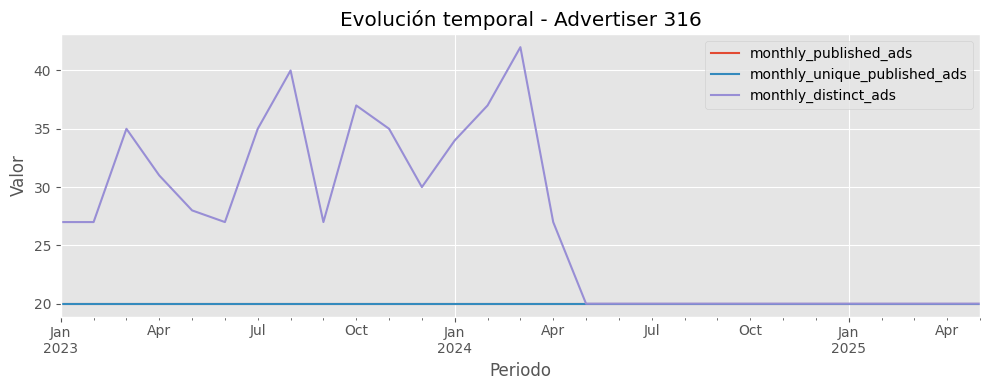

In [147]:
cols = [
    "monthly_published_ads",
    "monthly_unique_published_ads",
    "monthly_distinct_ads",
]

plot_advertiser_timeseries(df_fct, 316, cols)

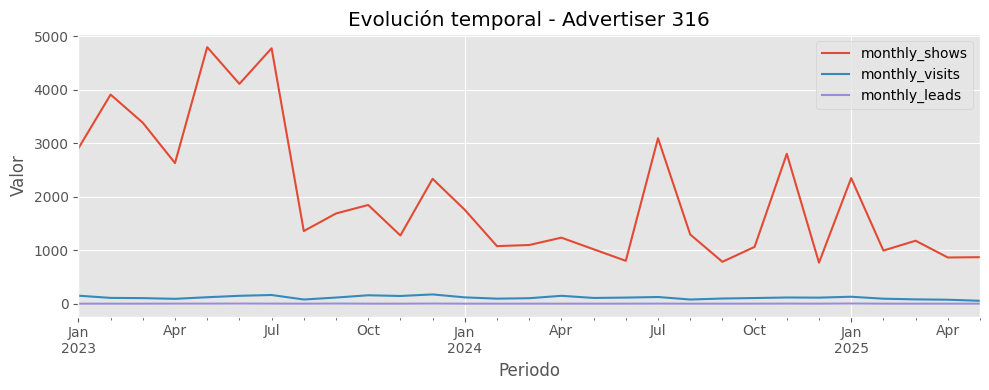

In [148]:
cols = [
    "monthly_shows",
    "monthly_visits",
    "monthly_leads"
]
plot_advertiser_timeseries(df_fct, 316, cols)

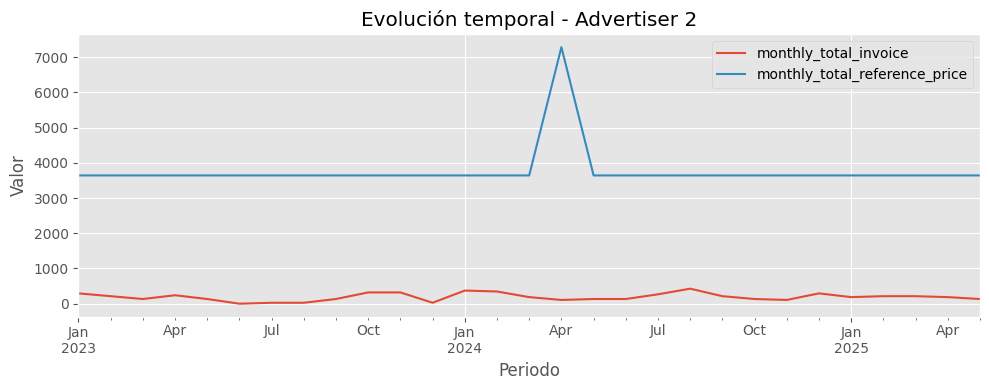

In [149]:
cols = [
    "monthly_total_invoice",
    "monthly_total_reference_price"
]
plot_advertiser_timeseries(df_fct, 2, cols)

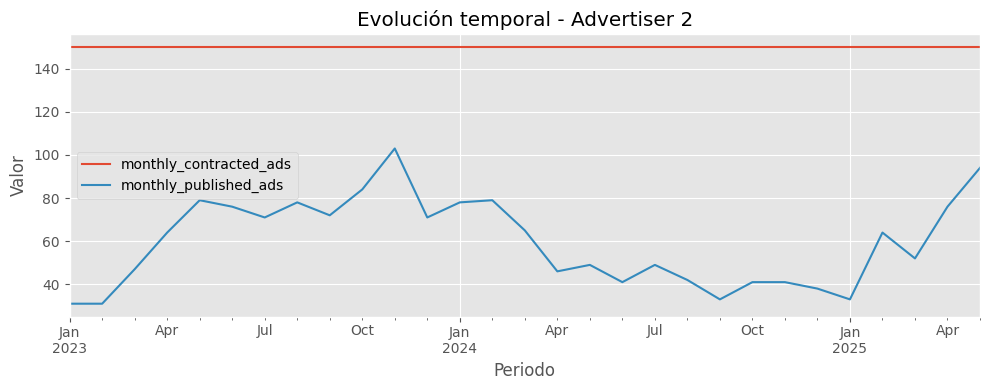

In [150]:
cols = [
    "monthly_contracted_ads",
    "monthly_published_ads",
]
plot_advertiser_timeseries(df_fct, 2, cols)

In [151]:
mask = (
    df_fct.groupby("advertiser_zrive_id")["period_int"].nunique() == 2
)

advertisers = mask[mask].index
df_fct[df_fct["advertiser_zrive_id"].isin(advertisers)]

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_phone_views,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract
136,178,2023-01-01,20,11,11,17.0,0,0,1,0,...,1,0,0,234.0,515.0,0,0,0,16197.06,True
217,294,2023-01-01,100,74,74,105.0,8,8,3,0,...,10,7,4,166.7,2210.0,7,14,21,34313.58,True
219,299,2023-01-01,14,14,14,28.0,1,2,0,0,...,5,6,2,175.0,730.0,6,6,12,26982.14,True
236,323,2023-01-01,75,42,42,47.0,4,4,1,0,...,5,3,1,0.0,NaN,3,3,6,34337.50,True
266,363,2023-01-01,100,89,89,109.0,5,5,0,0,...,8,7,1,1463.0,2596.7,4,5,9,24165.09,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96778,6997,2025-05-01,3,2,2,2.0,0,0,2,0,...,1,0,2,43.3,175.0,0,3,3,8500.00,True
96779,6998,2025-05-01,35,35,35,33.0,0,1,6,0,...,19,31,11,0.0,NaN,21,38,59,34735.45,True
96780,6999,2025-05-01,20,9,9,23.0,2,2,5,0,...,1,5,4,0.0,NaN,5,12,17,42137.83,True
96781,7000,2025-05-01,10,7,7,9.0,1,1,4,0,...,0,2,0,95.0,381.7,2,2,4,14688.89,True


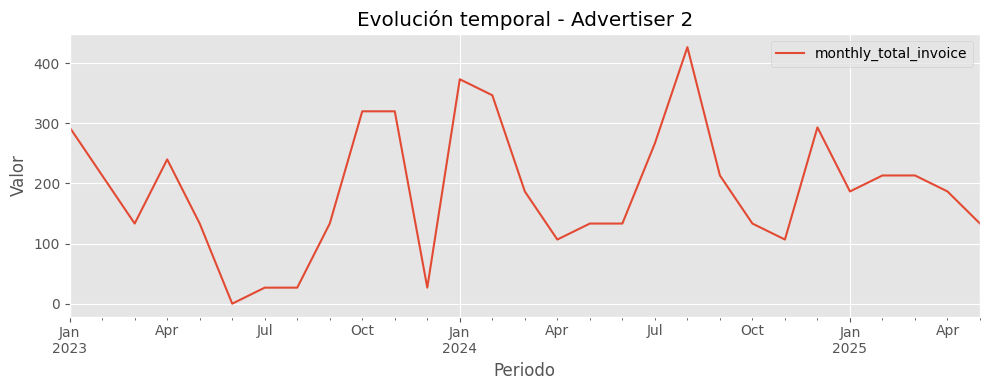

In [152]:
cols = [
    "monthly_total_invoice"
]
plot_advertiser_timeseries(df_fct, 2, cols)

<Axes: >

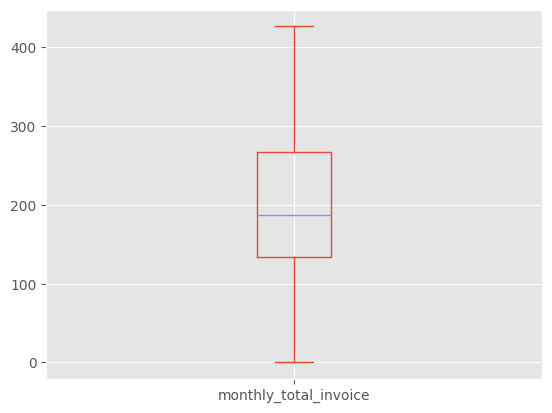

In [153]:
df_fct[df_fct["advertiser_zrive_id"] == 2]["monthly_total_invoice"].plot(kind='box')